# Techna — Full Showcase (end-to-end, AAPL)

**Purpose:** a single real run of Techna's full pipeline, with every output
baked in as *actually executed* cell output — the terminal dashboard, all 17
generated charts, every module's plain-English `finding`, and a live test
suite run. This demonstrates the tool working end-to-end on real data, for
anyone viewing this file standalone (no sibling files required — every
image below is embedded directly in this notebook, not linked by path).

> **This complements, and does not replace, two other correctness artifacts:**
> - `notebooks/proof_of_correctness.ipynb` — cross-checks individual
>   indicator math (RSI/MACD/Bollinger/ADX) against an independent
>   third-party library and known-answer test cases. This notebook does
>   not re-verify that math; it demonstrates the complete tool working.
> - The offline pytest suite (150+ tests) — the actual, continuously
>   enforced correctness gate. This notebook's live test-suite cell reports
>   its result but is not a substitute for running it in CI.
>
> Generated by `tools/build_showcase_notebook.py` (re-run to refresh with
> live data; requires network access + `pip install -r requirements-notebook.txt`).

## 1. Run Techna end-to-end on a real ticker

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "techna").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import importlib.util
_spec = importlib.util.spec_from_file_location("techna_cli", str(ROOT / "techna.py"))
techna_cli = importlib.util.module_from_spec(_spec)
sys.modules["techna_cli"] = techna_cli
_spec.loader.exec_module(techna_cli)

from rich.console import Console

TICKER = "AAPL"
OUT_DIR = ROOT / "notebooks" / "_showcase_output"
OUT_DIR.mkdir(parents=True, exist_ok=True)

console = Console(record=True, width=110)
exit_code = techna_cli.run(
    TICKER,
    no_interactive=True,
    explain=True,
    out_dir=str(OUT_DIR),
    console=console,
)
print(f"exit code: {exit_code}")
assert exit_code == 0, "Techna run failed -- showcase notebook cannot proceed"

╭────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│                  Techna Summary Dashboard · AAPL                                                           │
│ ┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┓                                          │
│ ┃ Indicator / Category ┃        Metric / Value ┃ State / Status ┃                                          │
│ ┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━┩                                          │
│ │ Last Close Price     │                289.36 │ Ok             │                                          │
│ │ Trend State          │ Price vs SMA50/SMA200 │ uptrend        │                                          │
│ │ RSI (14)             │                 46.93 │ neutral        │                                          │
│ │ MACD State           │         Hist: -2.0990 │ bearish        │                                          │
│ │ Bollinger Bands      │            %B: 0.3314 │ within_bands   │                                          │
│ │ Trend Regime (ADX)   │             ADX: 25.6 │ trending_down  │                                          │
│ │ Volatility Regime    │             ATR: 8.26 │ high           │                                          │
│ │ Price/RSI Divergence │         swing compare │ none           │                                          │
│ │ Relative Strength    │                vs SPY │ neutral        │                                          │
│ │ OBV Divergence       │  slope: -2182218.0827 │ confirming     │                                          │
│ │ Price vs VWAP        │          dist: -1.41% │ below_vwap     │                                          │
│ │ Vol. Clustering      │          ARCH effects │ detected       │                                          │
│ │ Normality (JB)       │         p-val: 0.0000 │ non-normal     │                                          │
│ │ 52w Range            │            pos: 77.3% │ mid_range      │                                          │
│ │ Max Drawdown         │          curr: -8.20% │ underwater     │                                          │
│ │ Liquidity            │     avg_v20: 19801.5M │ high_liquidity │                                          │
│ │ Beta vs SPY          │            beta: 1.11 │ market_beta    │                                          │
│ └──────────────────────┴───────────────────────┴────────────────┘                                          │
╰────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│                   Techna Score Profile (Independent Dimensions)                                            │
│ ┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓                          │
│ ┃ Dimension        ┃ Score (0-100) ┃ Bar Chart            ┃ State Label         ┃                          │
│ ┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩                          │
│ │ Trend Strength   │            85 │ #################--- │ strong              │                          │
│ │ Momentum         │            32 │ ######-------------- │ bearish             │                          │
│ │ Trend Maturity   │            77 │ ###############----- │ mid                 │                          │
│ │ Liquidity        │           100 │ #################### │ high                │                          │
│ │ Volatility Level │            93 │ ##################-- │ high                │                          │
│ │ Statistical Edge │            50 │ ##########---------- │ insufficient_sample │                          │
│ └──────────────────┴───────────────┴──────────────────────┴─────────────────────┘                          │
╰────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────────────── Synthesis — Not Advice ──────────────────────────────────────────╮
│ ## Executive Summary                                                                                       │
│ Trend strength is characterized as strong (score: 85/100) and the ADX regime is ranging. Current momentum  │
│ is bearish (score: 32/100).                                                                                │
│                                                                                                            │
│ ## Contradictions                                                                                          │
│ The trend is strong, but momentum is bearish, indicating potential divergence or cooling-off within a      │
│ mature trend structure.                                                                                    │
│                                                                                                            │
│ ## Disclaimer                                                                                              │
│ These are descriptive observations of historical and current technical data; all investment decisions and  │
│ their consequences are solely the user's responsibility.                                                   │
╰────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Warnings: History is short (n=501); tail statistics (kurtosis) are unreliable - consider --period 5y

Reminder: Techna reports signal states, never buy/sell advice.

Static notebook generated successfully at: C:\TECHNA\notebooks\_showcase_output\AAPL_report.ipynb

Report and chart generated successfully at: C:\TECHNA\notebooks\_showcase_output\AAPL_report.md

Structured results written to: C:\TECHNA\notebooks\_showcase_output\AAPL_result.json

exit code: 0


## 2. Terminal dashboard (as the user actually sees it)

In [2]:
terminal_output = console.export_text(styles=False)
print(terminal_output)

╭────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│                  Techna Summary Dashboard · AAPL                                                           │
│ ┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┓                                          │
│ ┃ Indicator / Category ┃        Metric / Value ┃ State / Status ┃                                          │
│ ┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━┩                                          │
│ │ Last Close Price     │                289.36 │ Ok             │                                          │
│ │ Trend State          │ Price vs SMA50/SMA200 │ uptrend        │                                          │
│ │ RSI (14)             │                 46.93 │ neutral        │                                          │
│ │ MACD State           │         Hist: -2.0990 │ bearish        │                                          │
│

## 3. Every module's plain-English finding (from the JSON sidecar)

These sentences are produced by the same functions that write the markdown
report (Phase 25's single-source `finding` fields) -- not reimplemented or
paraphrased here.

In [3]:
import json

result = json.loads((OUT_DIR / f"{TICKER}_result.json").read_text(encoding="utf-8"))
print(f"Overall status: {result['status']}\n")
for m in result["modules"]:
    print(f"[{m['module']:12}] {m['metrics'].get('finding', '(no finding)')}")

Overall status: ok

[trend       ] Current trend state is uptrend. Last crossover: golden on 2025-09-15.
[momentum    ] RSI is 46.93 (neutral); MACD histogram is negative (-2.0990), indicating bearish momentum.
[volatility  ] Bollinger Bands state is within_bands with %B at 0.3314 (Upper: 315.39, Lower: 276.46).
[levels      ] Key support levels are [194.18, 207.27, 223.01, 246.25, 267.98] and key resistance levels are [212.64, 232.87, 238.47, 257.35, 273.91].
[context     ] Trend regime is trending_down (ADX: 25.56), volatility regime is high (ATR: 8.26); divergence: no divergence detected.
[relative    ] Relative strength vs SPY is in a neutral state (RS Ratio: 0.387482 vs SMA: 0.397723).
[seasonality ] Monthly seasonality highlights: Aug historically performs best with an average return of 7.60% and a win rate of 100.00%.
[volume      ] OBV trend/divergence is confirming (Price slope: -1.351986, OBV slope: -2182218.082707); VWAP (20) state is below_vwap (Distance: -1.41%).
[economet

## 4. All 17 generated charts, each with the exact code that drew it

Every chart Techna produced for this run, embedded directly (not linked by path
-- these are real pixels baked into this .ipynb file). Immediately above each
image is the **live source** of the `report_builder.draw_*_chart` function that
drew it, fetched with `inspect.getsource()` at notebook-build time -- not
copy-pasted, so it can never silently go stale relative to the real code.

In [4]:
import inspect
from IPython.display import Image, display
from techna import report_builder

chart_suffixes = [
    "overview", "momentum", "regime", "candles", "levels", "baserates",
    "relative", "seasonality", "volume", "correlogram", "distribution",
    "52week", "drawdown", "beta", "structural_breaks", "hurst", "quantile_beta",
]
chart_files = [OUT_DIR / f"{TICKER}_{suffix}.png" for suffix in chart_suffixes]
existing = [p for p in chart_files if p.exists()]
print(f"{len(existing)} / {len(chart_files)} expected charts found.")

17 / 17 expected charts found.


### `AAPL_overview.png`

In [5]:
print(inspect.getsource(report_builder.draw_overview_chart))

def draw_overview_chart(
    ticker: str,
    df: pd.DataFrame,
    trend_data: Dict[str, Any],
    volatility_data: Dict[str, Any],
    levels_data: Dict[str, Any],
    out_path: Path,
) -> None:
    """Price panel (Close, MAs, Bollinger, pivots) over a volume panel."""
    fig, (ax1, ax2) = plt.subplots(
        nrows=2, ncols=1, sharex=True, figsize=(12, 8),
        gridspec_kw={"height_ratios": [3, 1]},
    )

    ax1.plot(df.index, df["Close"], label="Close", color="#1f77b4", linewidth=1.4)
    for key, label, color in (
        ("sma20", "SMA 20", "#9467bd"),
        ("sma50", "SMA 50", "#ff7f0e"),
        ("sma200", "SMA 200", "#d62728"),
    ):
        series = trend_data.get(key)
        if series is not None:
            ax1.plot(df.index, series, label=label, linestyle="--", linewidth=1.0, color=color)

    if volatility_data.get("upper") is not None:
        ax1.plot(df.index, volatility_data["upper"], color="#2ca02c", linestyle=":", alpha=0.7, label="Bollinger")
        ax

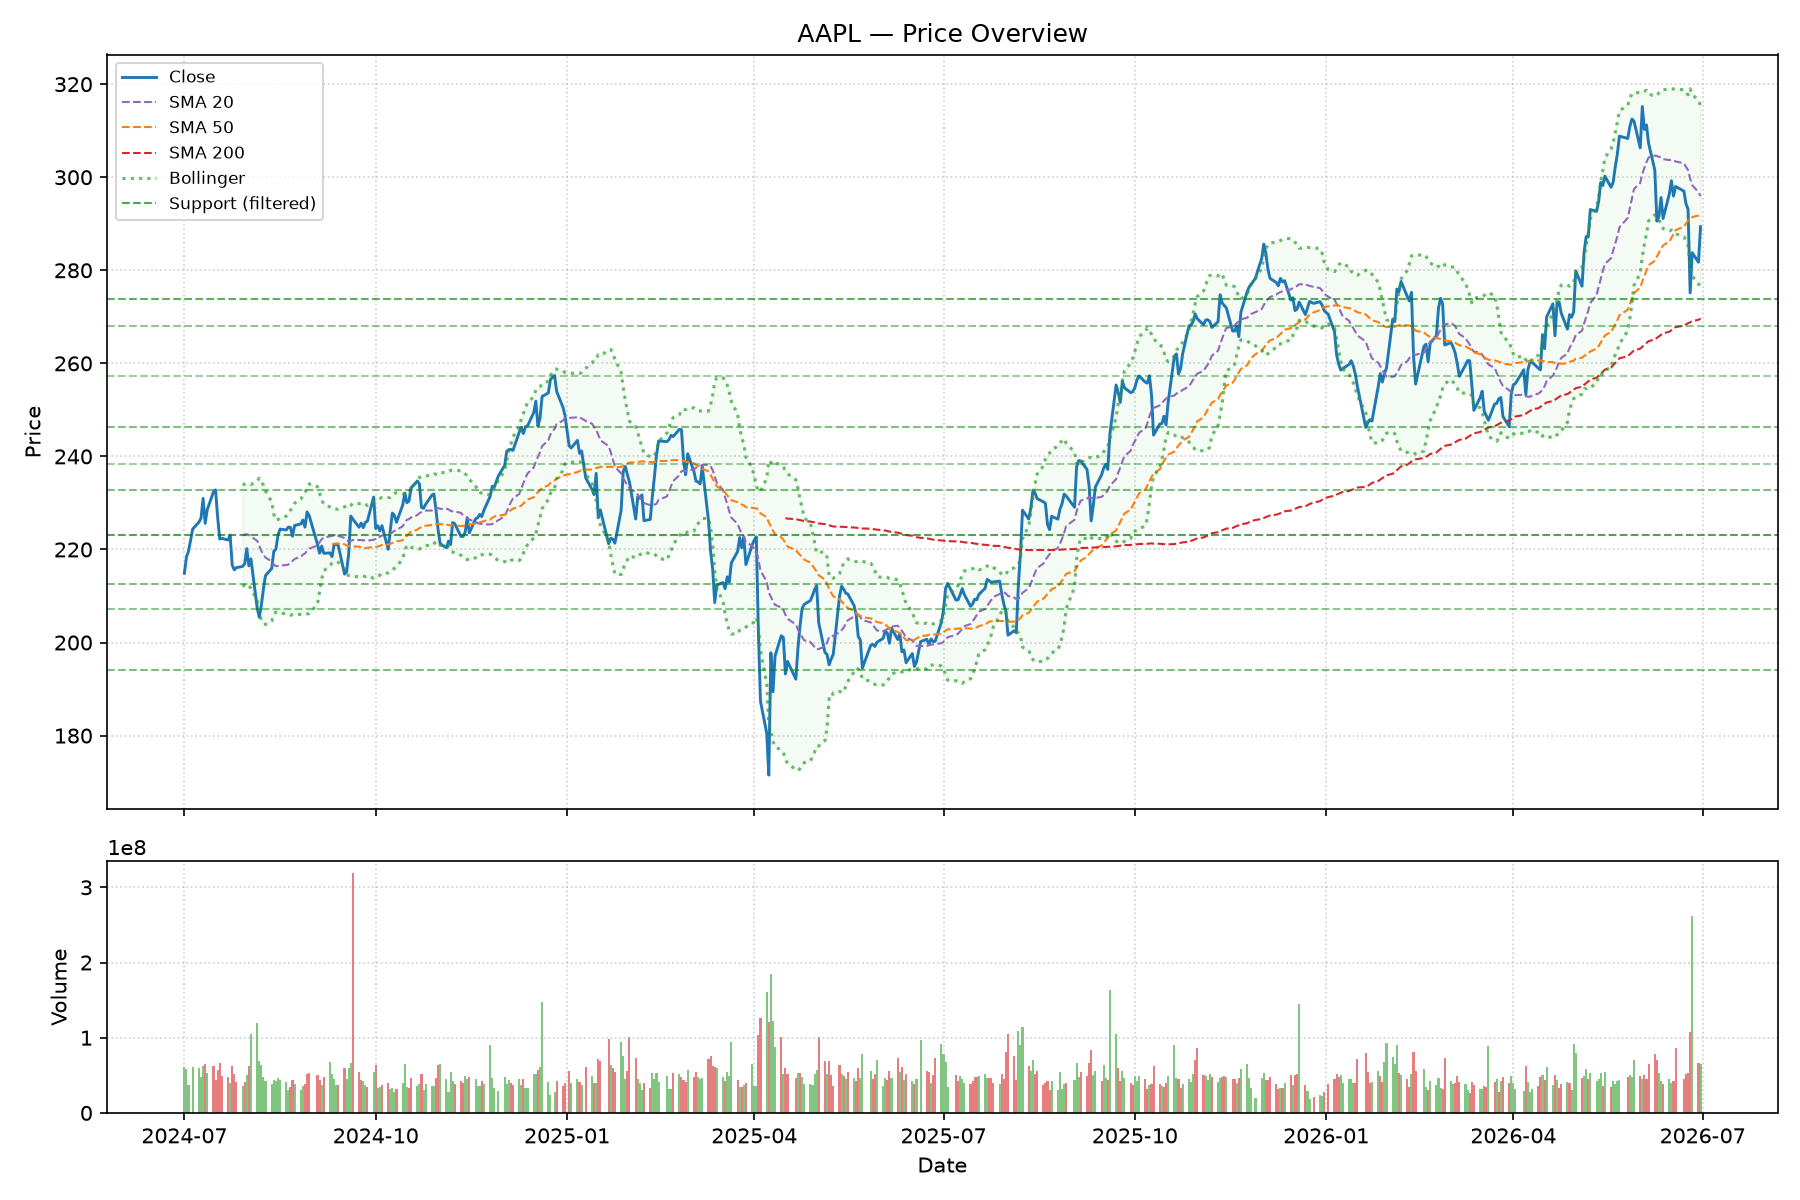

In [6]:
p = OUT_DIR / f"{TICKER}_overview.png"
display(Image(filename=str(p))) if p.exists() else print("(chart not generated for this run)")

### `AAPL_momentum.png`

In [7]:
print(inspect.getsource(report_builder.draw_momentum_chart))

def draw_momentum_chart(
    ticker: str,
    df: pd.DataFrame,
    momentum_data: Dict[str, Any],
    context_data: Dict[str, Any] | None,
    out_path: Path,
) -> None:
    """RSI panel (with zones + divergence note) over a MACD panel."""
    fig, (ax1, ax2) = plt.subplots(
        nrows=2, ncols=1, sharex=True, figsize=(12, 7),
        gridspec_kw={"height_ratios": [1, 1]},
    )

    rsi_s = momentum_data.get("rsi")
    if rsi_s is not None:
        ax1.plot(df.index, rsi_s, label="RSI (14)", color="#9467bd", linewidth=1.2)
        ax1.axhspan(config.RSI_OVERBOUGHT, 100, color="red", alpha=0.07)
        ax1.axhspan(0, config.RSI_OVERSOLD, color="green", alpha=0.07)
        ax1.axhline(config.RSI_OVERBOUGHT, color="red", linestyle="--", alpha=0.5, linewidth=0.8)
        ax1.axhline(config.RSI_OVERSOLD, color="green", linestyle="--", alpha=0.5, linewidth=0.8)
        ax1.set_ylim(0, 100)
        ax1.set_ylabel("RSI")
        ax1.legend(loc="upper left", fontsize=8)
        ax1.grid(T

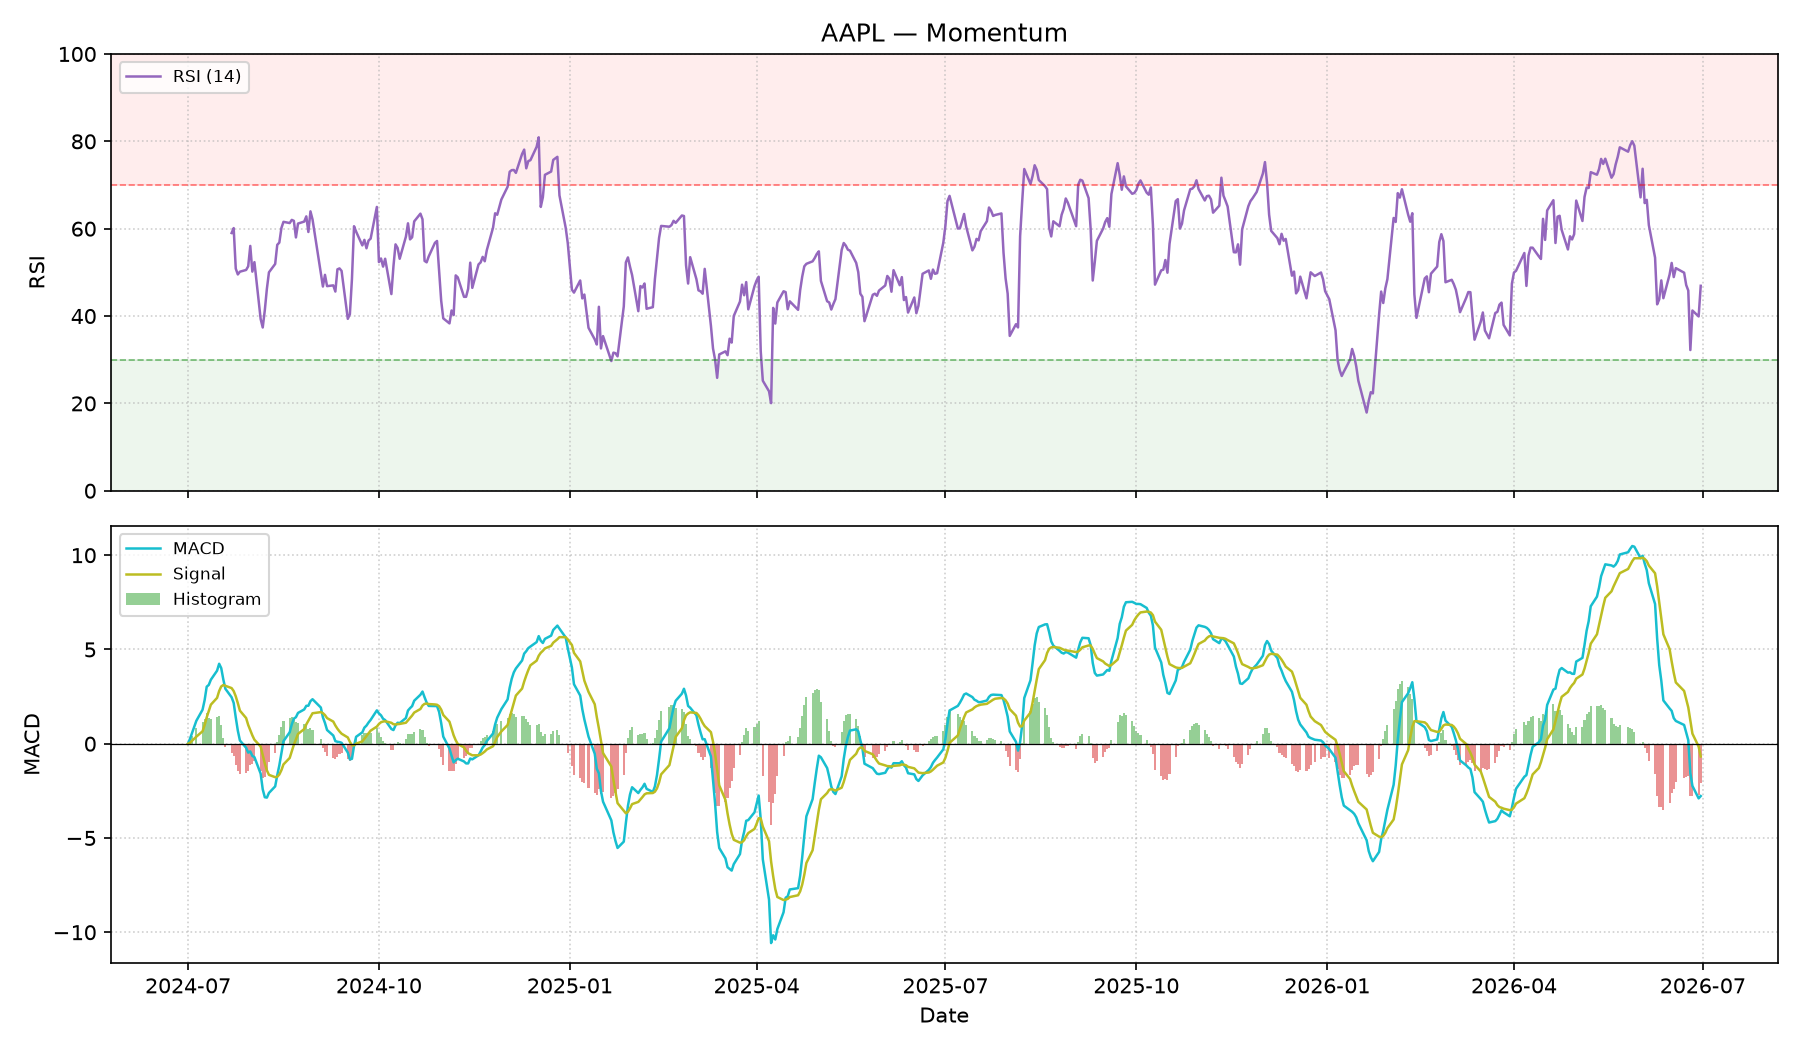

In [8]:
p = OUT_DIR / f"{TICKER}_momentum.png"
display(Image(filename=str(p))) if p.exists() else print("(chart not generated for this run)")

### `AAPL_regime.png`

In [9]:
print(inspect.getsource(report_builder.draw_regime_chart))

def draw_regime_chart(
    ticker: str,
    df: pd.DataFrame,
    context_data: Dict[str, Any],
    out_path: Path,
) -> None:
    """ADX/+DI/-DI panel (trend strength) over an ATR panel (volatility)."""
    fig, (ax1, ax2) = plt.subplots(
        nrows=2, ncols=1, sharex=True, figsize=(12, 7),
        gridspec_kw={"height_ratios": [1, 1]},
    )

    adx_df = context_data.get("adx")
    if adx_df is not None:
        ax1.plot(df.index, adx_df["adx"], label="ADX", color="#000000", linewidth=1.4)
        ax1.plot(df.index, adx_df["plus_di"], label="+DI", color="#2ca02c", linewidth=1.0)
        ax1.plot(df.index, adx_df["minus_di"], label="-DI", color="#d62728", linewidth=1.0)
        ax1.axhline(config.ADX_TREND_THRESHOLD, color="gray", linestyle="--", alpha=0.7,
                    linewidth=0.8, label=f"Trend threshold ({config.ADX_TREND_THRESHOLD:.0f})")
        ax1.set_ylabel("ADX / DI")
        ax1.legend(loc="upper left", fontsize=8)
        ax1.grid(True, linestyle=":", alpha=0.6

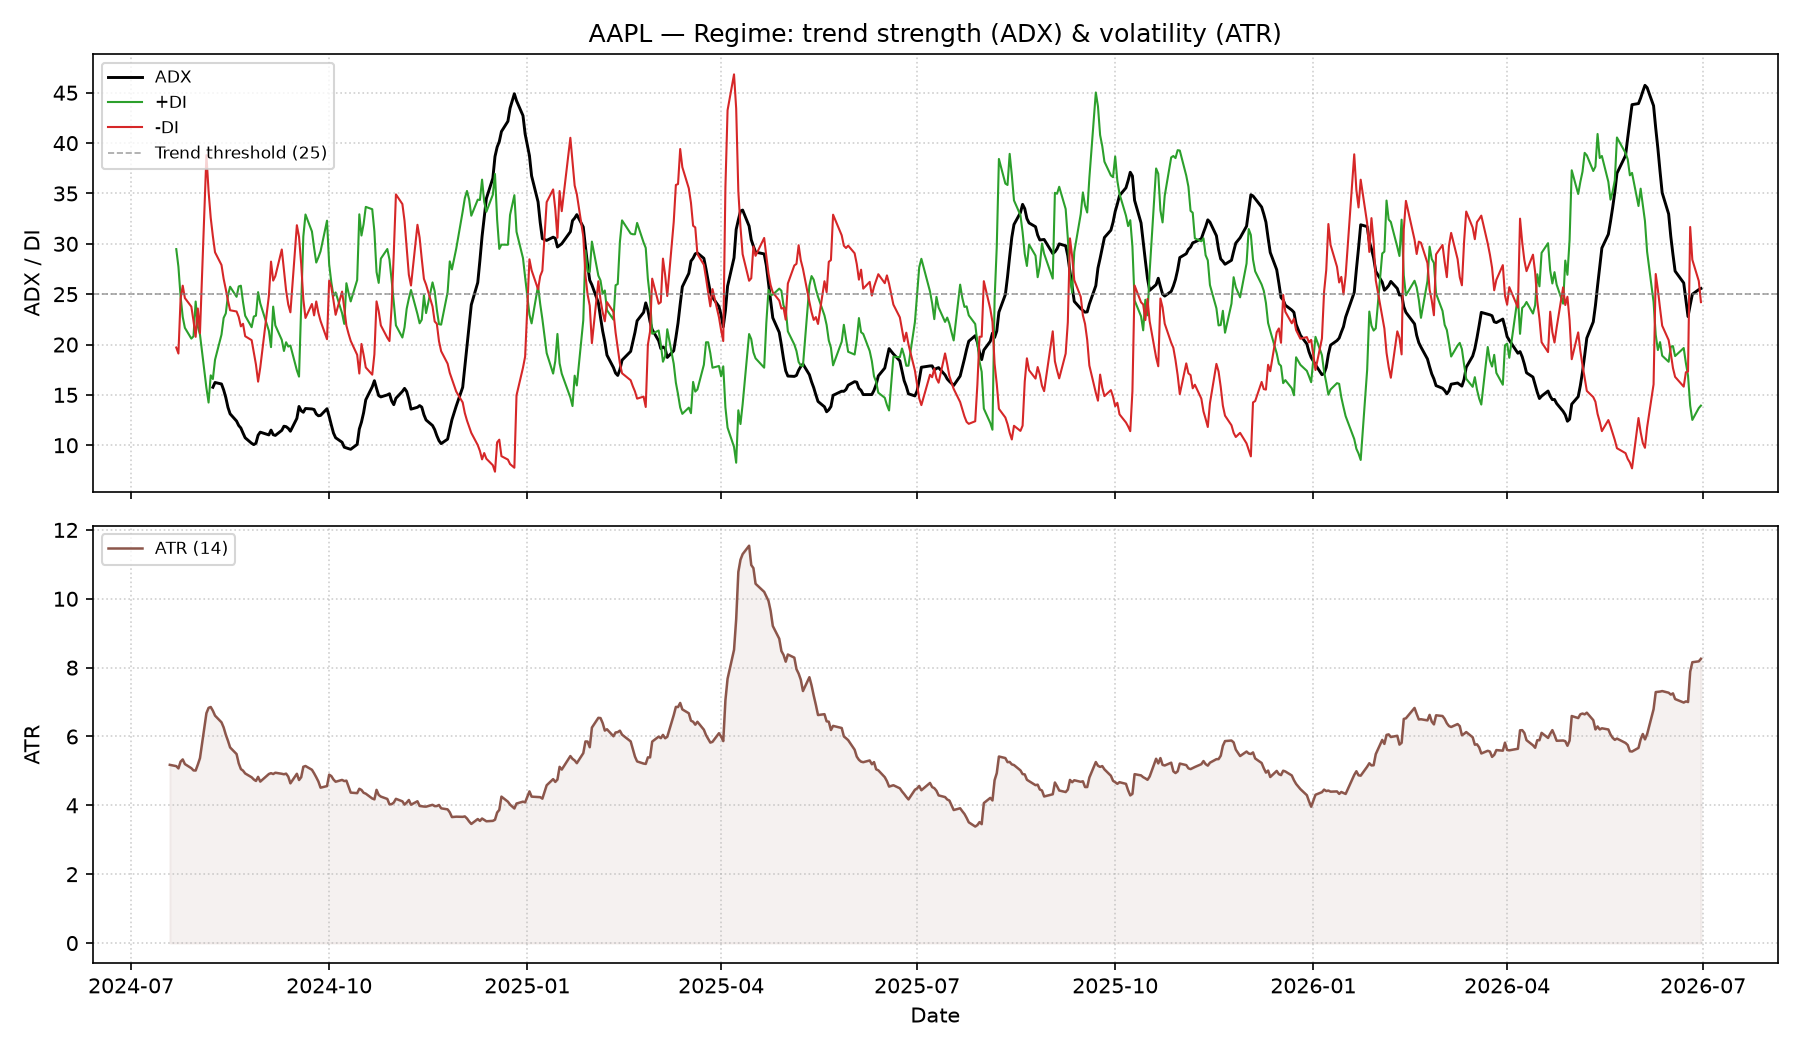

In [10]:
p = OUT_DIR / f"{TICKER}_regime.png"
display(Image(filename=str(p))) if p.exists() else print("(chart not generated for this run)")

### `AAPL_candles.png`

In [11]:
print(inspect.getsource(report_builder.draw_candles_chart))

def draw_candles_chart(
    ticker: str,
    df: pd.DataFrame,
    trend_data: Dict[str, Any],
    out_path: Path,
    n: int = CANDLE_WINDOW,
) -> None:
    """Manual candlestick of the most recent `n` bars with MA overlays.

    Drawn by hand (no mplfinance) so we add no new dependency. Uses integer
    x-positions so weekend/holiday gaps don't distort candle widths.
    """
    sub = df.iloc[-n:]
    x = np.arange(len(sub))
    o = sub["Open"].to_numpy()
    c = sub["Close"].to_numpy()
    h = sub["High"].to_numpy()
    low = sub["Low"].to_numpy()
    up = c >= o

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.vlines(x, low, h, color="#333333", linewidth=0.7, zorder=1)
    bottoms = np.minimum(o, c)
    heights = np.maximum(np.abs(c - o), 1e-9)
    ax.bar(x[up], heights[up], bottom=bottoms[up], width=0.6, color="#2ca02c", zorder=2)
    ax.bar(x[~up], heights[~up], bottom=bottoms[~up], width=0.6, color="#d62728", zorder=2)

    for key, label, color in (
        ("sma20", "SMA 20

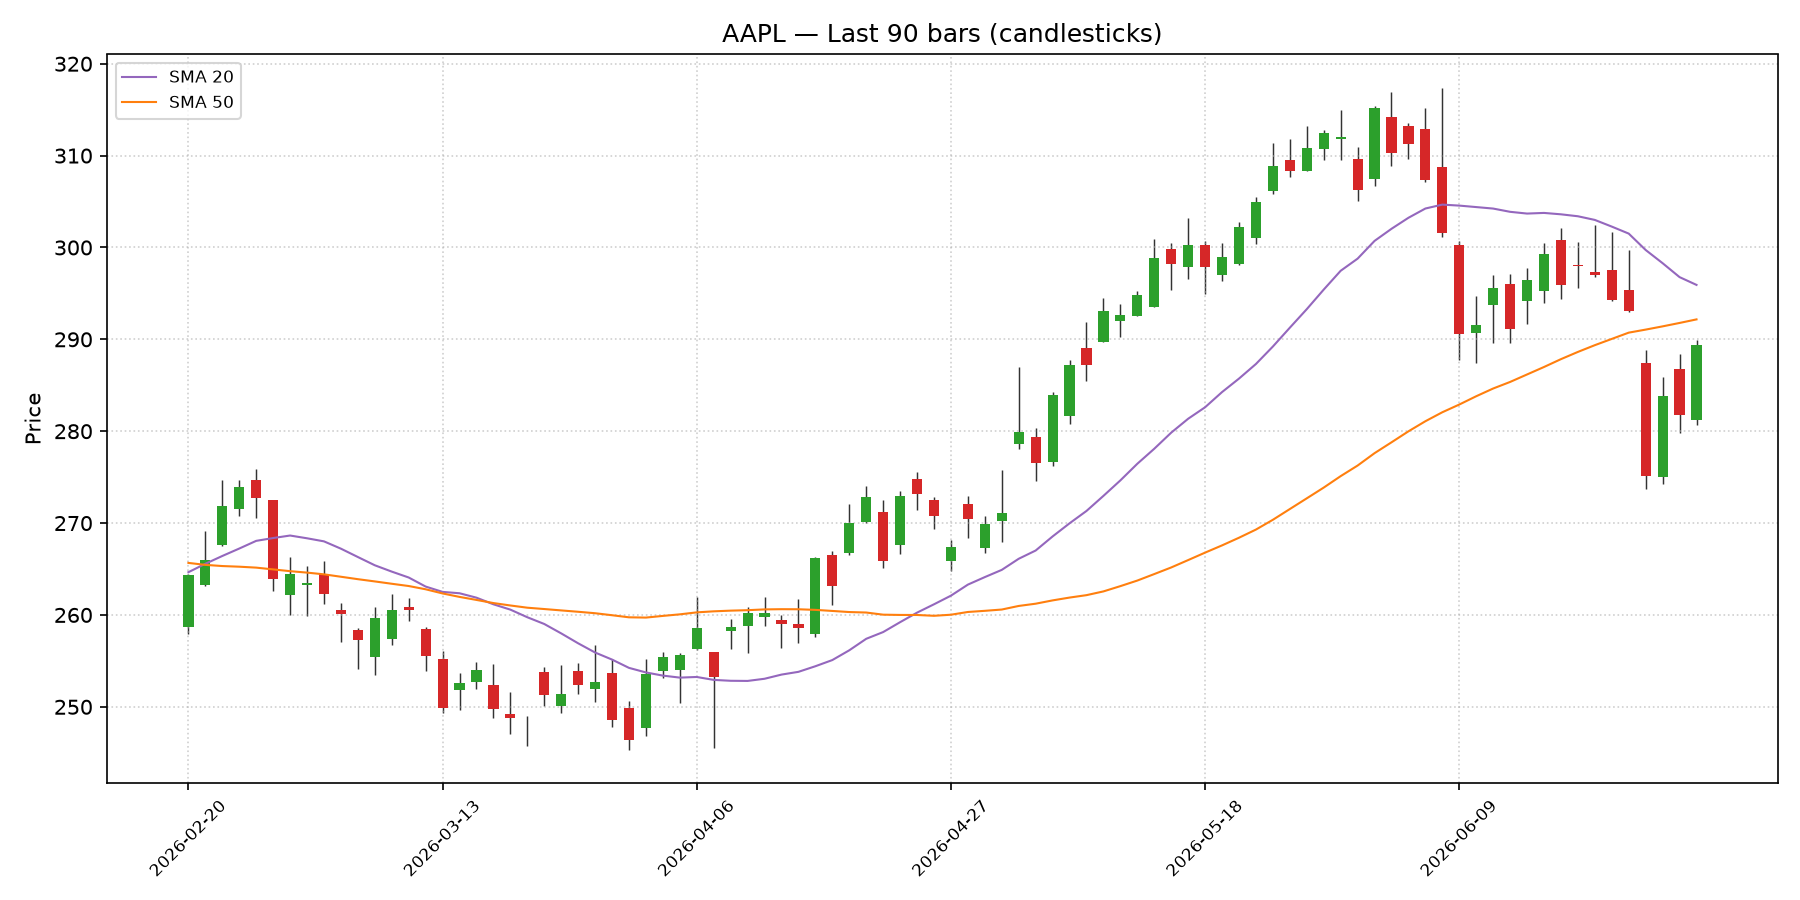

In [12]:
p = OUT_DIR / f"{TICKER}_candles.png"
display(Image(filename=str(p))) if p.exists() else print("(chart not generated for this run)")

### `AAPL_levels.png`

In [13]:
print(inspect.getsource(report_builder.draw_levels_chart))

def draw_levels_chart(
    ticker: str,
    df: pd.DataFrame,
    levels_v2: dict,
    out_path: Path,
) -> None:
    """Price line + horizontal lines for the strongest N support (green) and resistance (red) levels.
    
    Line thickness/alpha is proportional to the touches (strength).
    """
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(df.index, df["Close"], label="Close Price", color="#1f77b4", linewidth=1.5)
    
    raw_supports = levels_v2.get("supports", [])
    raw_resistances = levels_v2.get("resistances", [])
    current_price = float(df["Close"].iloc[-1])
    
    # Merge levels and combine touches for identical prices
    combined_levels: dict[float, dict[str, Any]] = {}
    for lvl in raw_supports + raw_resistances:
        price = lvl["price"]
        touches = lvl["touches"]
        if price in combined_levels:
            combined_levels[price]["touches"] += touches
        else:
            combined_levels[price] = {"price": price, "touches": touches}
    

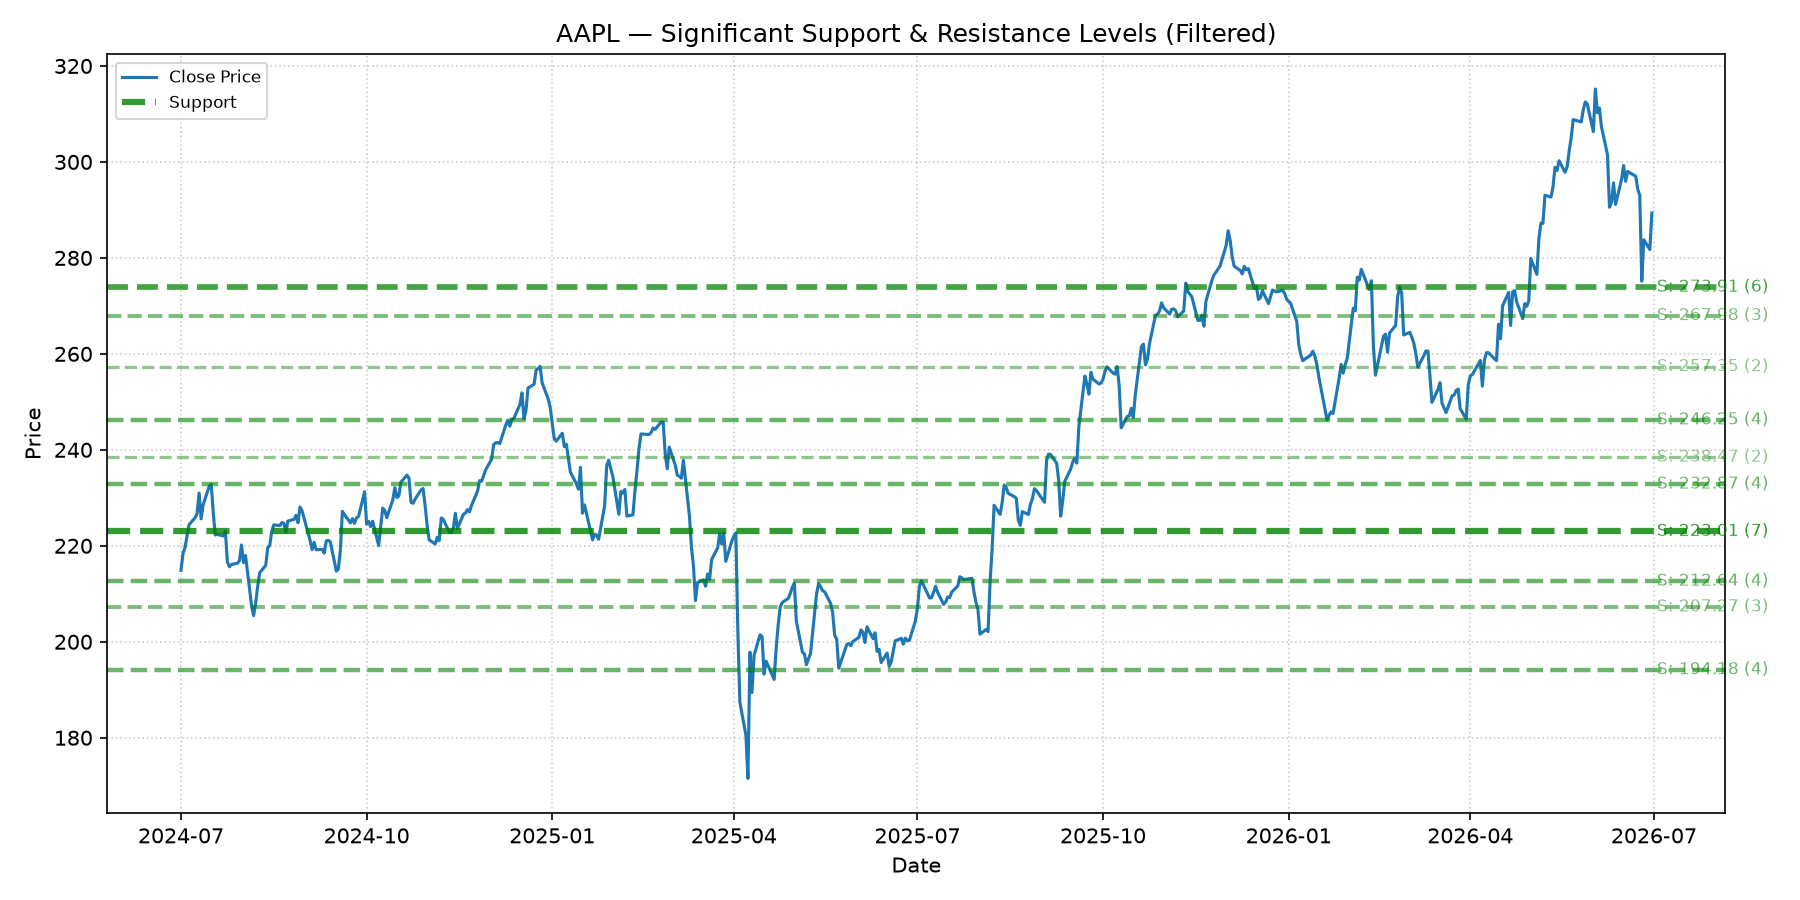

In [14]:
p = OUT_DIR / f"{TICKER}_levels.png"
display(Image(filename=str(p))) if p.exists() else print("(chart not generated for this run)")

### `AAPL_baserates.png`

In [15]:
print(inspect.getsource(report_builder.draw_baserates_chart))

def draw_baserates_chart(
    ticker: str,
    fwd10: pd.Series,
    cond_rsi: pd.Series,
    cond_boll: pd.Series,
    out_path: Path,
) -> None:
    """Plot histograms of conditional forward returns vs baseline returns."""
    df_rsi = pd.DataFrame({"cond": cond_rsi, "fwd": fwd10}).dropna()
    rsi_fwd = df_rsi.loc[df_rsi["cond"], "fwd"]
    
    df_boll = pd.DataFrame({"cond": cond_boll, "fwd": fwd10}).dropna()
    boll_fwd = df_boll.loc[df_boll["cond"], "fwd"]
    
    baseline = fwd10.dropna()
    
    fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(12, 8))
    
    if len(rsi_fwd) > 0 and len(baseline) > 0:
        ax1.hist(baseline * 100, bins=20, alpha=0.3, color="gray", label="Baseline (All Days)", density=True)
        ax1.hist(rsi_fwd * 100, bins=15, alpha=0.6, color="orange", label="RSI >= 70", density=True)
        
        base_mean = baseline.mean() * 100
        rsi_mean = rsi_fwd.mean() * 100
        ax1.axvline(base_mean, color="gray", linestyle="--", linewi

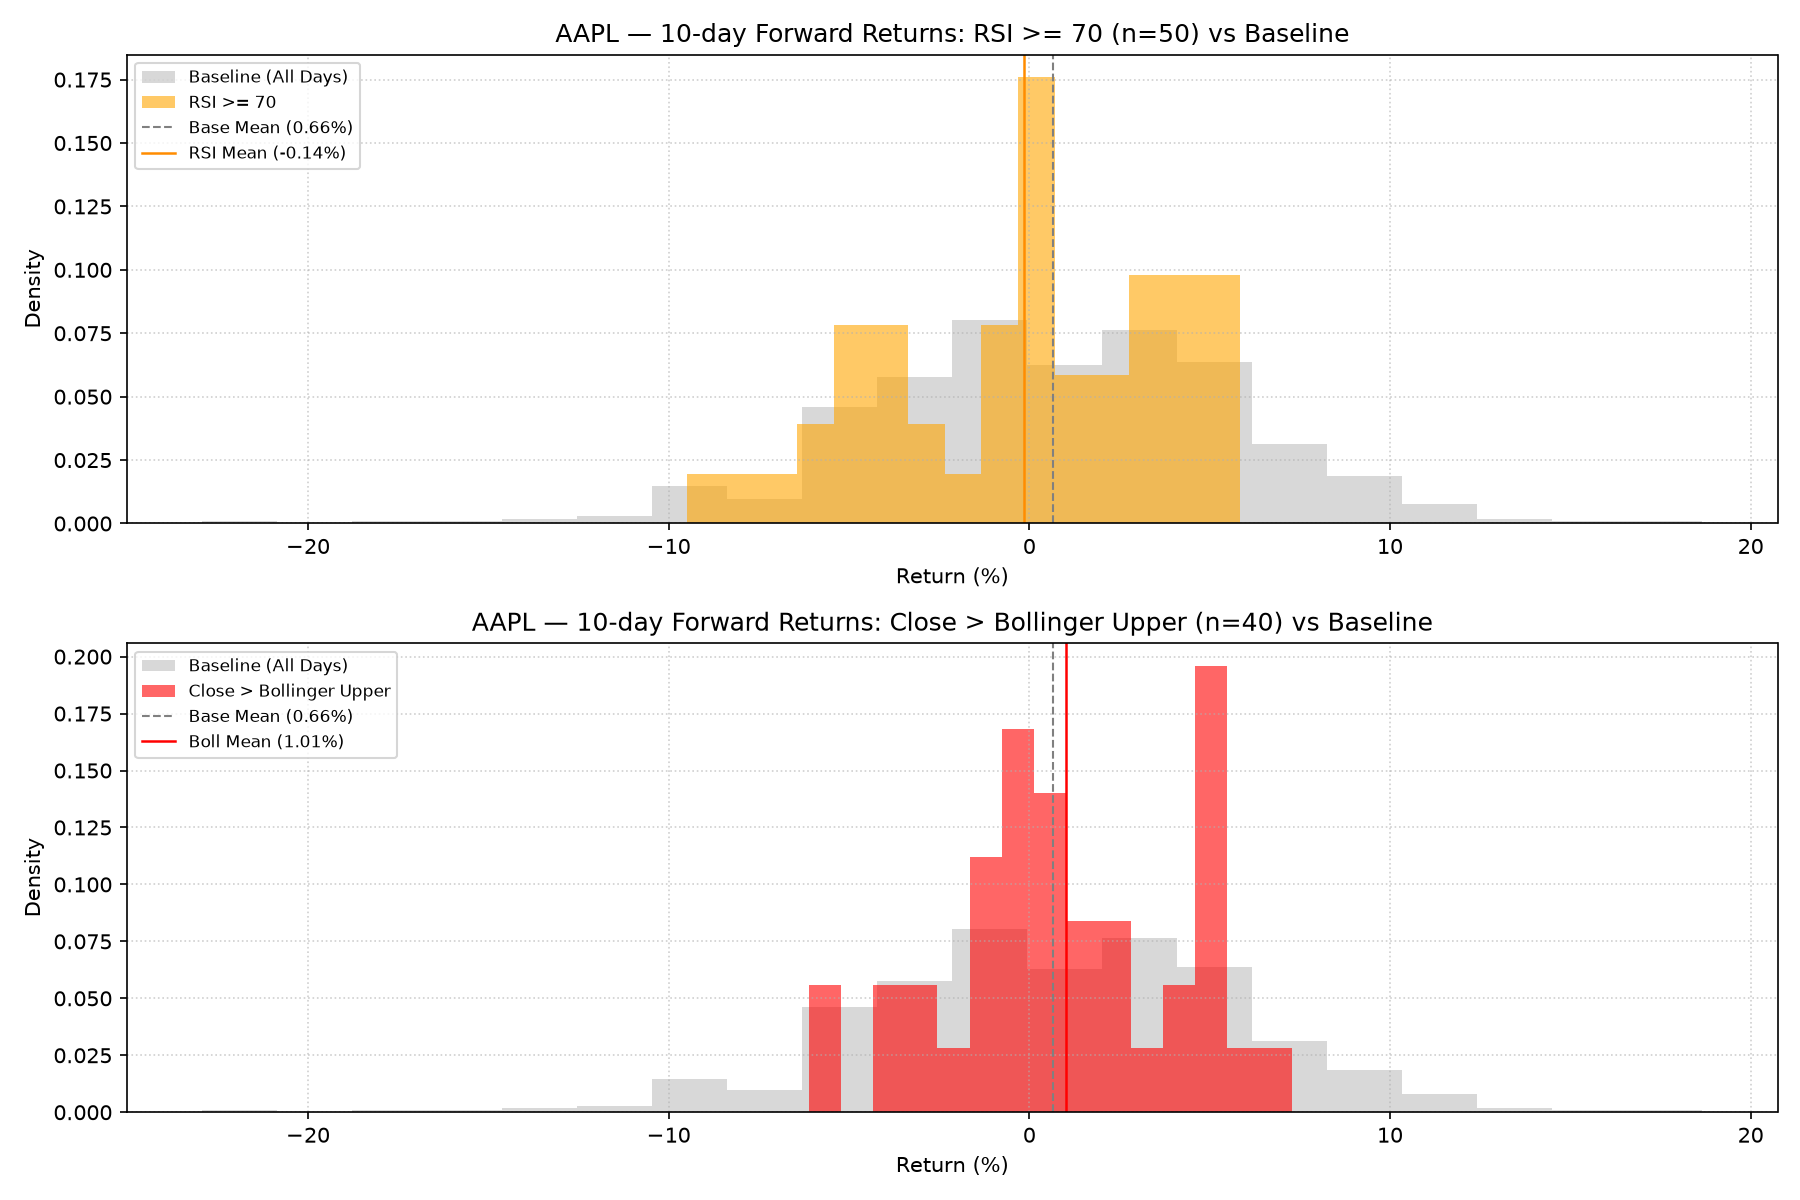

In [16]:
p = OUT_DIR / f"{TICKER}_baserates.png"
display(Image(filename=str(p))) if p.exists() else print("(chart not generated for this run)")

### `AAPL_relative.png`

In [17]:
print(inspect.getsource(report_builder.draw_relative_chart))

def draw_relative_chart(
    ticker: str,
    benchmark_ticker: str,
    asset_rebased: pd.Series,
    bench_rebased: pd.Series,
    rs: pd.Series,
    rs_ma: pd.Series,
    out_path: Path,
) -> None:
    """Plot rebased relative performance and RS ratio vs its SMA."""
    fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(12, 8))
    
    ax1.plot(asset_rebased.index, asset_rebased, label=f"{ticker} (Rebased)", color="#1f77b4", linewidth=1.5)
    ax1.plot(bench_rebased.index, bench_rebased, label=f"{benchmark_ticker} (Rebased)", color="#ff7f0e", linewidth=1.2)
    ax1.axhline(100, color="black", linestyle="--", linewidth=0.8, alpha=0.7)
    ax1.set_ylabel("Performance (Base 100)")
    ax1.set_title(f"{ticker} vs {benchmark_ticker} — Rebased Performance Comparison")
    ax1.legend(loc="upper left", fontsize=8)
    ax1.grid(True, linestyle=":", alpha=0.6)
    
    ax2.plot(rs.index, rs, label="Relative Strength Ratio", color="purple", linewidth=1.5)
    ax2.plot(rs_m

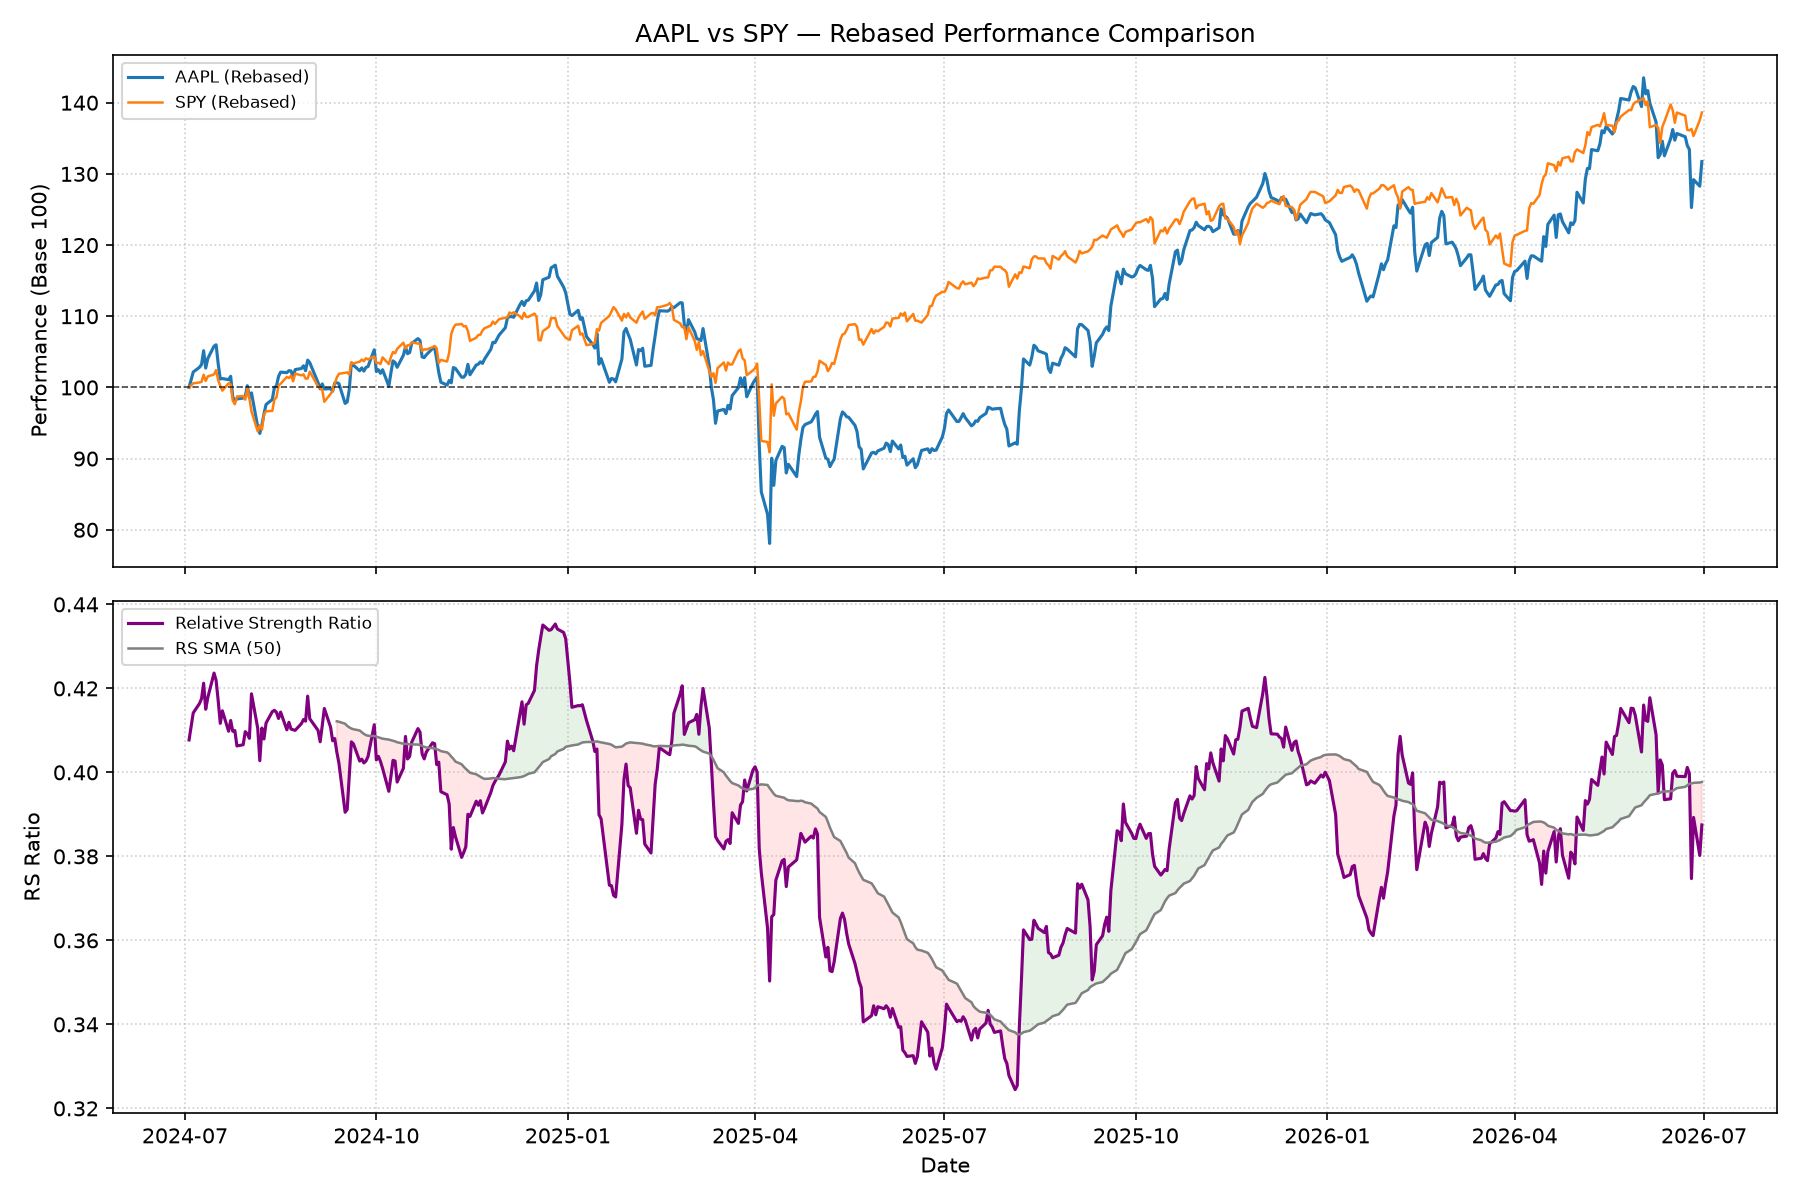

In [18]:
p = OUT_DIR / f"{TICKER}_relative.png"
display(Image(filename=str(p))) if p.exists() else print("(chart not generated for this run)")

### `AAPL_seasonality.png`

In [19]:
print(inspect.getsource(report_builder.draw_seasonality_chart))

def draw_seasonality_chart(
    ticker: str,
    table: pd.DataFrame,
    out_path: Path,
) -> None:
    """Plot seasonality heatmap of monthly returns using pure matplotlib (no Seaborn)."""
    pct_table = table * 100.0
    avg_row = pct_table.mean(axis=0)
    
    years = list(pct_table.index)
    row_labels = [str(y) for y in years] + ["Avg"]
    col_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
    
    grid_data = np.vstack([pct_table.values, avg_row.values])
    
    fig, ax = plt.subplots(figsize=(12, len(row_labels) * 0.7 + 2))
    
    from matplotlib.colors import TwoSlopeNorm
    
    val_min = np.nanmin(grid_data) if not np.isnan(grid_data).all() else -1.0
    val_max = np.nanmax(grid_data) if not np.isnan(grid_data).all() else 1.0
    if val_min >= 0:
        val_min = -1.0
    if val_max <= 0:
        val_max = 1.0
        
    norm = TwoSlopeNorm(vmin=val_min, vcenter=0.0, vmax=val_max)
    im = ax.imshow(grid_data, cmap="R

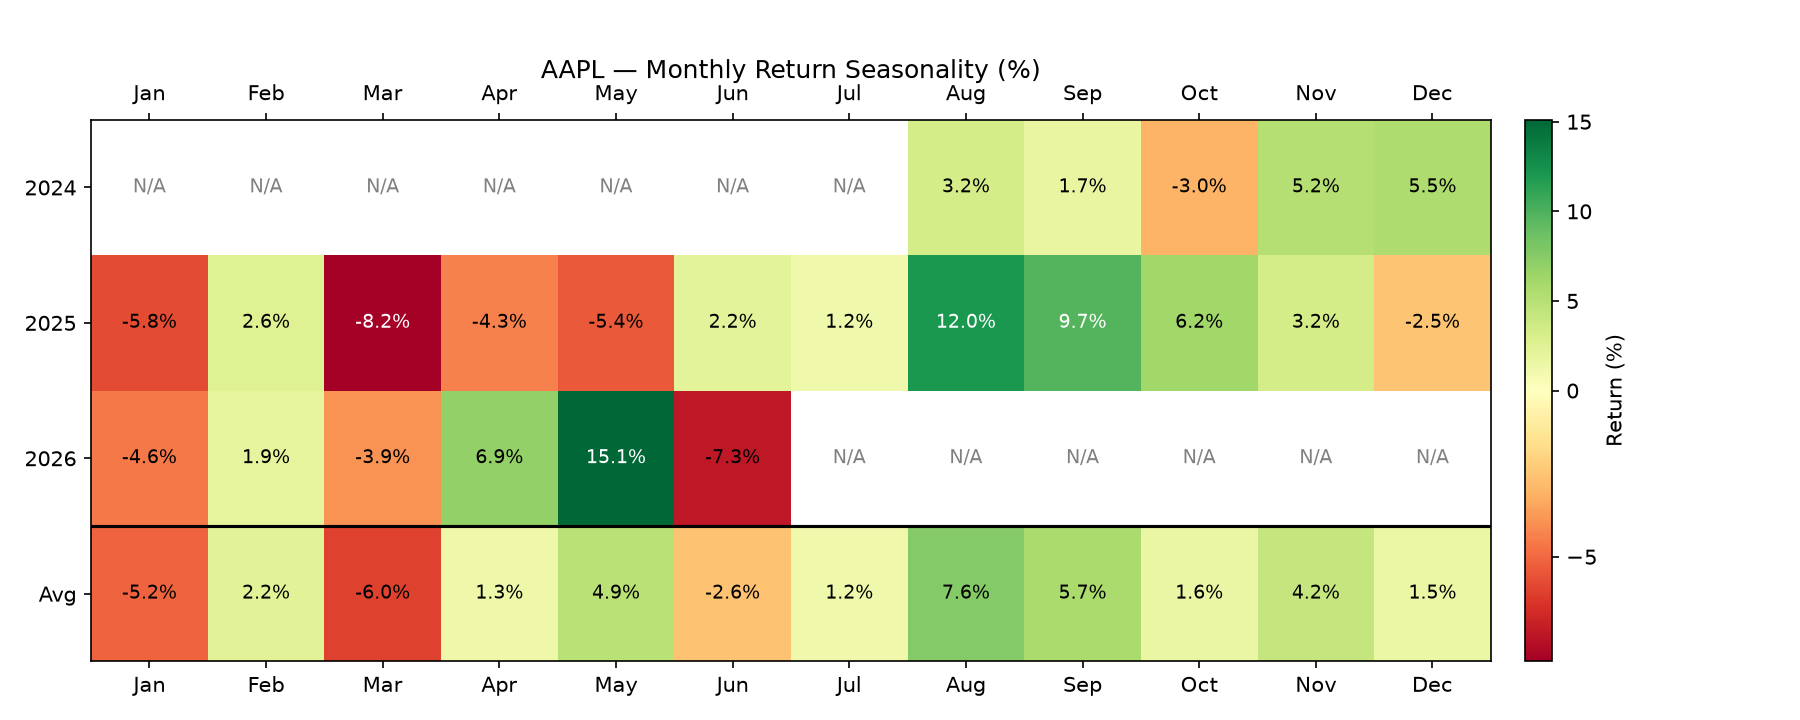

In [20]:
p = OUT_DIR / f"{TICKER}_seasonality.png"
display(Image(filename=str(p))) if p.exists() else print("(chart not generated for this run)")

### `AAPL_volume.png`

In [21]:
print(inspect.getsource(report_builder.draw_volume_chart))

def draw_volume_chart(
    ticker: str,
    df: pd.DataFrame,
    vwap: pd.Series,
    obv: pd.Series,
    out_path: Path,
) -> None:
    """Plot volume indicators (VWAP, Volume bars, and OBV) using pure matplotlib."""
    fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(12, 8))
    
    ax1.plot(df.index, df["Close"], label=f"{ticker} Close", color="#1f77b4", linewidth=1.5)
    ax1.plot(vwap.index, vwap, label="VWAP (20)", color="orange", linestyle="--", linewidth=1.5)
    ax1.set_ylabel("Price")
    ax1.set_title(f"{ticker} — Close Price vs VWAP (20) & Volume/OBV")
    ax1.legend(loc="upper left", fontsize=8)
    ax1.grid(True, linestyle=":", alpha=0.6)
    
    colors = []
    close_vals = df["Close"].values
    for i in range(len(df)):
        if i == 0:
            colors.append("gray")
        elif close_vals[i] >= close_vals[i-1]:
            colors.append("green")
        else:
            colors.append("red")
            
    ax2.bar(df.index, df["Volume"

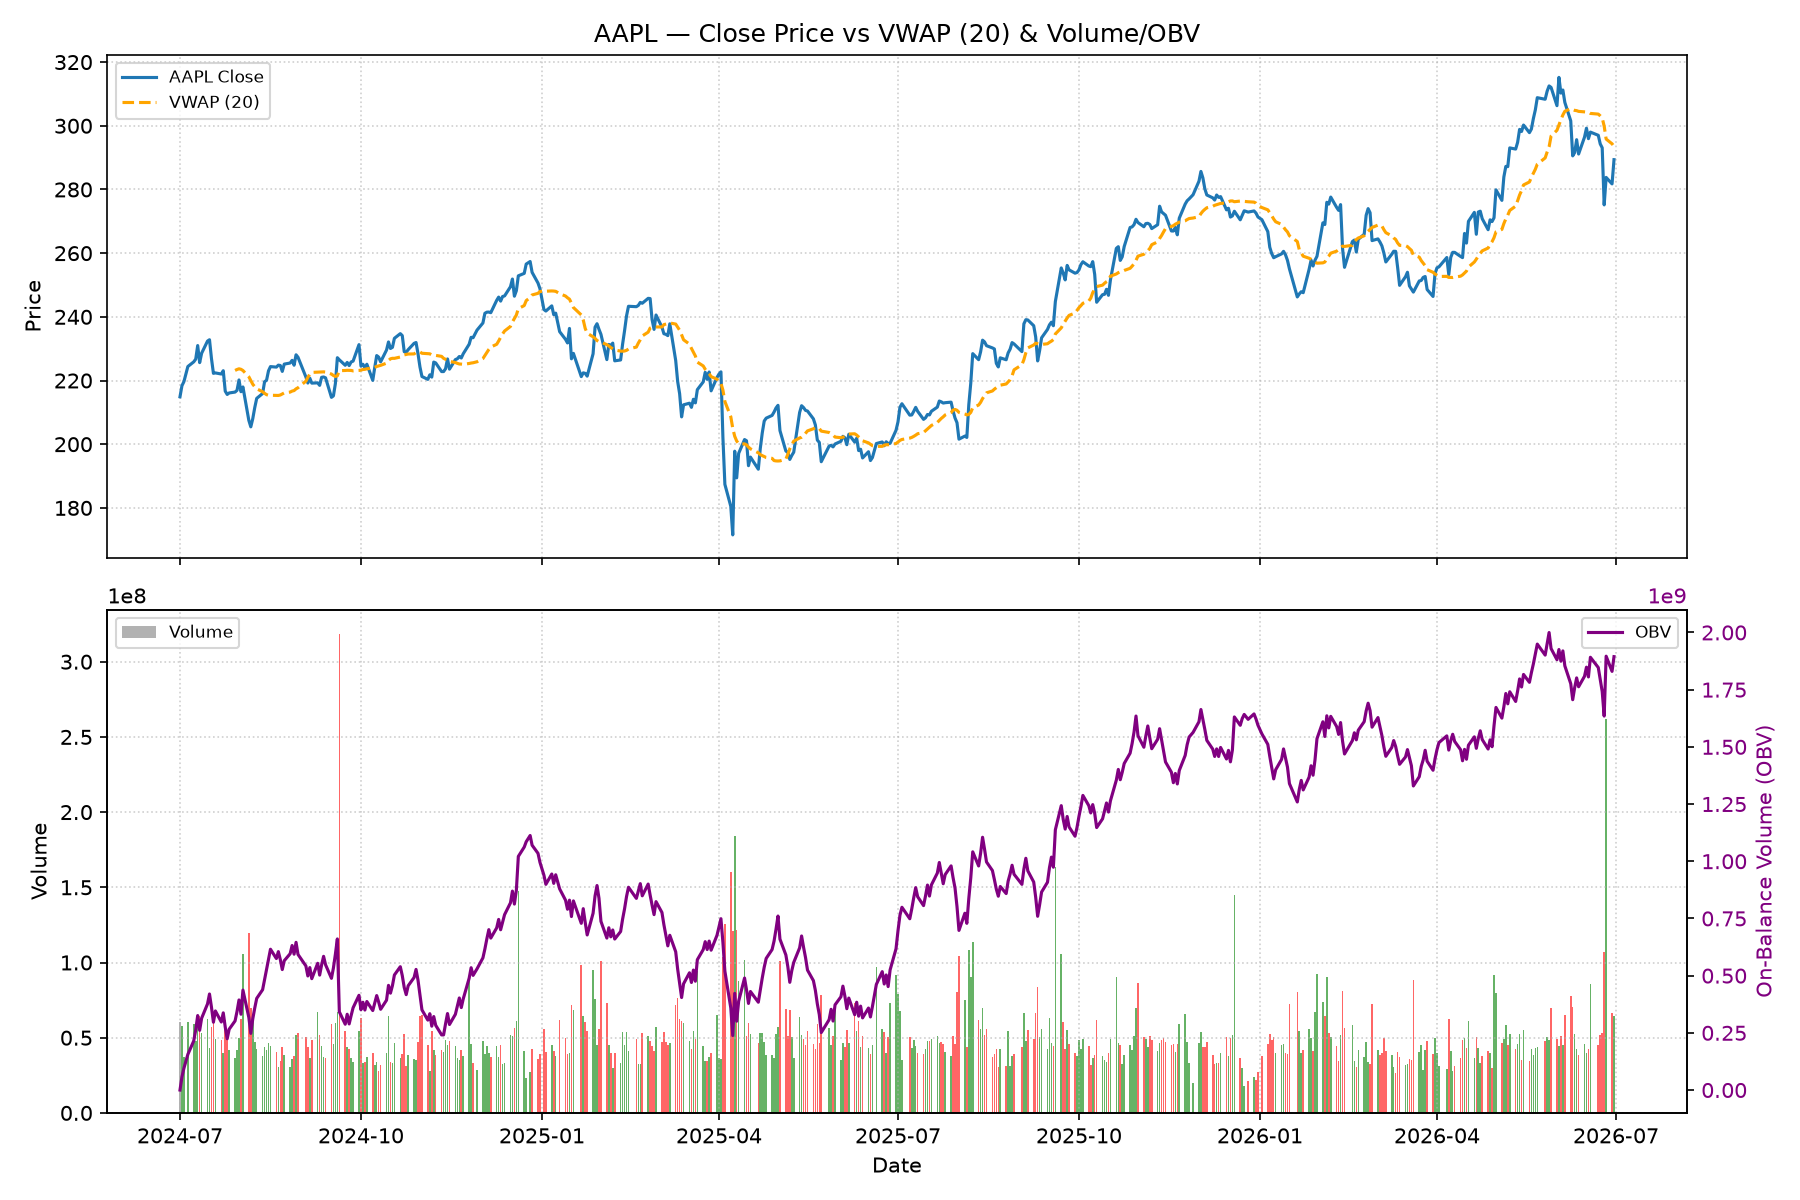

In [22]:
p = OUT_DIR / f"{TICKER}_volume.png"
display(Image(filename=str(p))) if p.exists() else print("(chart not generated for this run)")

### `AAPL_correlogram.png`

In [23]:
print(inspect.getsource(report_builder.draw_correlogram_chart))

def draw_correlogram_chart(
    ticker: str,
    acf_pacf_data: dict,
    out_path: Path,
) -> None:
    """Plot ACF stems for raw, absolute, and squared returns with a confidence band."""
    fig, (ax1, ax2, ax3) = plt.subplots(nrows=3, ncols=1, figsize=(12, 10), sharex=True)
    
    conf = acf_pacf_data["conf"]
    lags_arr = np.arange(len(acf_pacf_data["raw"]["acf"]))
    
    def _draw_sub(ax, acf_vals, title, color):
        ax.stem(lags_arr, acf_vals, linefmt=f"{color}-", markerfmt=f"{color}o", basefmt="k-", label="ACF")
        ax.axhspan(-conf, conf, color="gray", alpha=0.2, label="95% CI")
        ax.set_ylabel("Autocorrelation")
        ax.set_title(title)
        ax.legend(loc="upper right", fontsize=8)
        ax.grid(True, linestyle=":", alpha=0.6)
        
    _draw_sub(ax1, acf_pacf_data["raw"]["acf"], f"{ticker} Raw Returns ACF", "b")
    _draw_sub(ax2, acf_pacf_data["abs"]["acf"], f"{ticker} Absolute Returns |r| ACF", "g")
    _draw_sub(ax3, acf_pacf_data["sq"]["acf"]

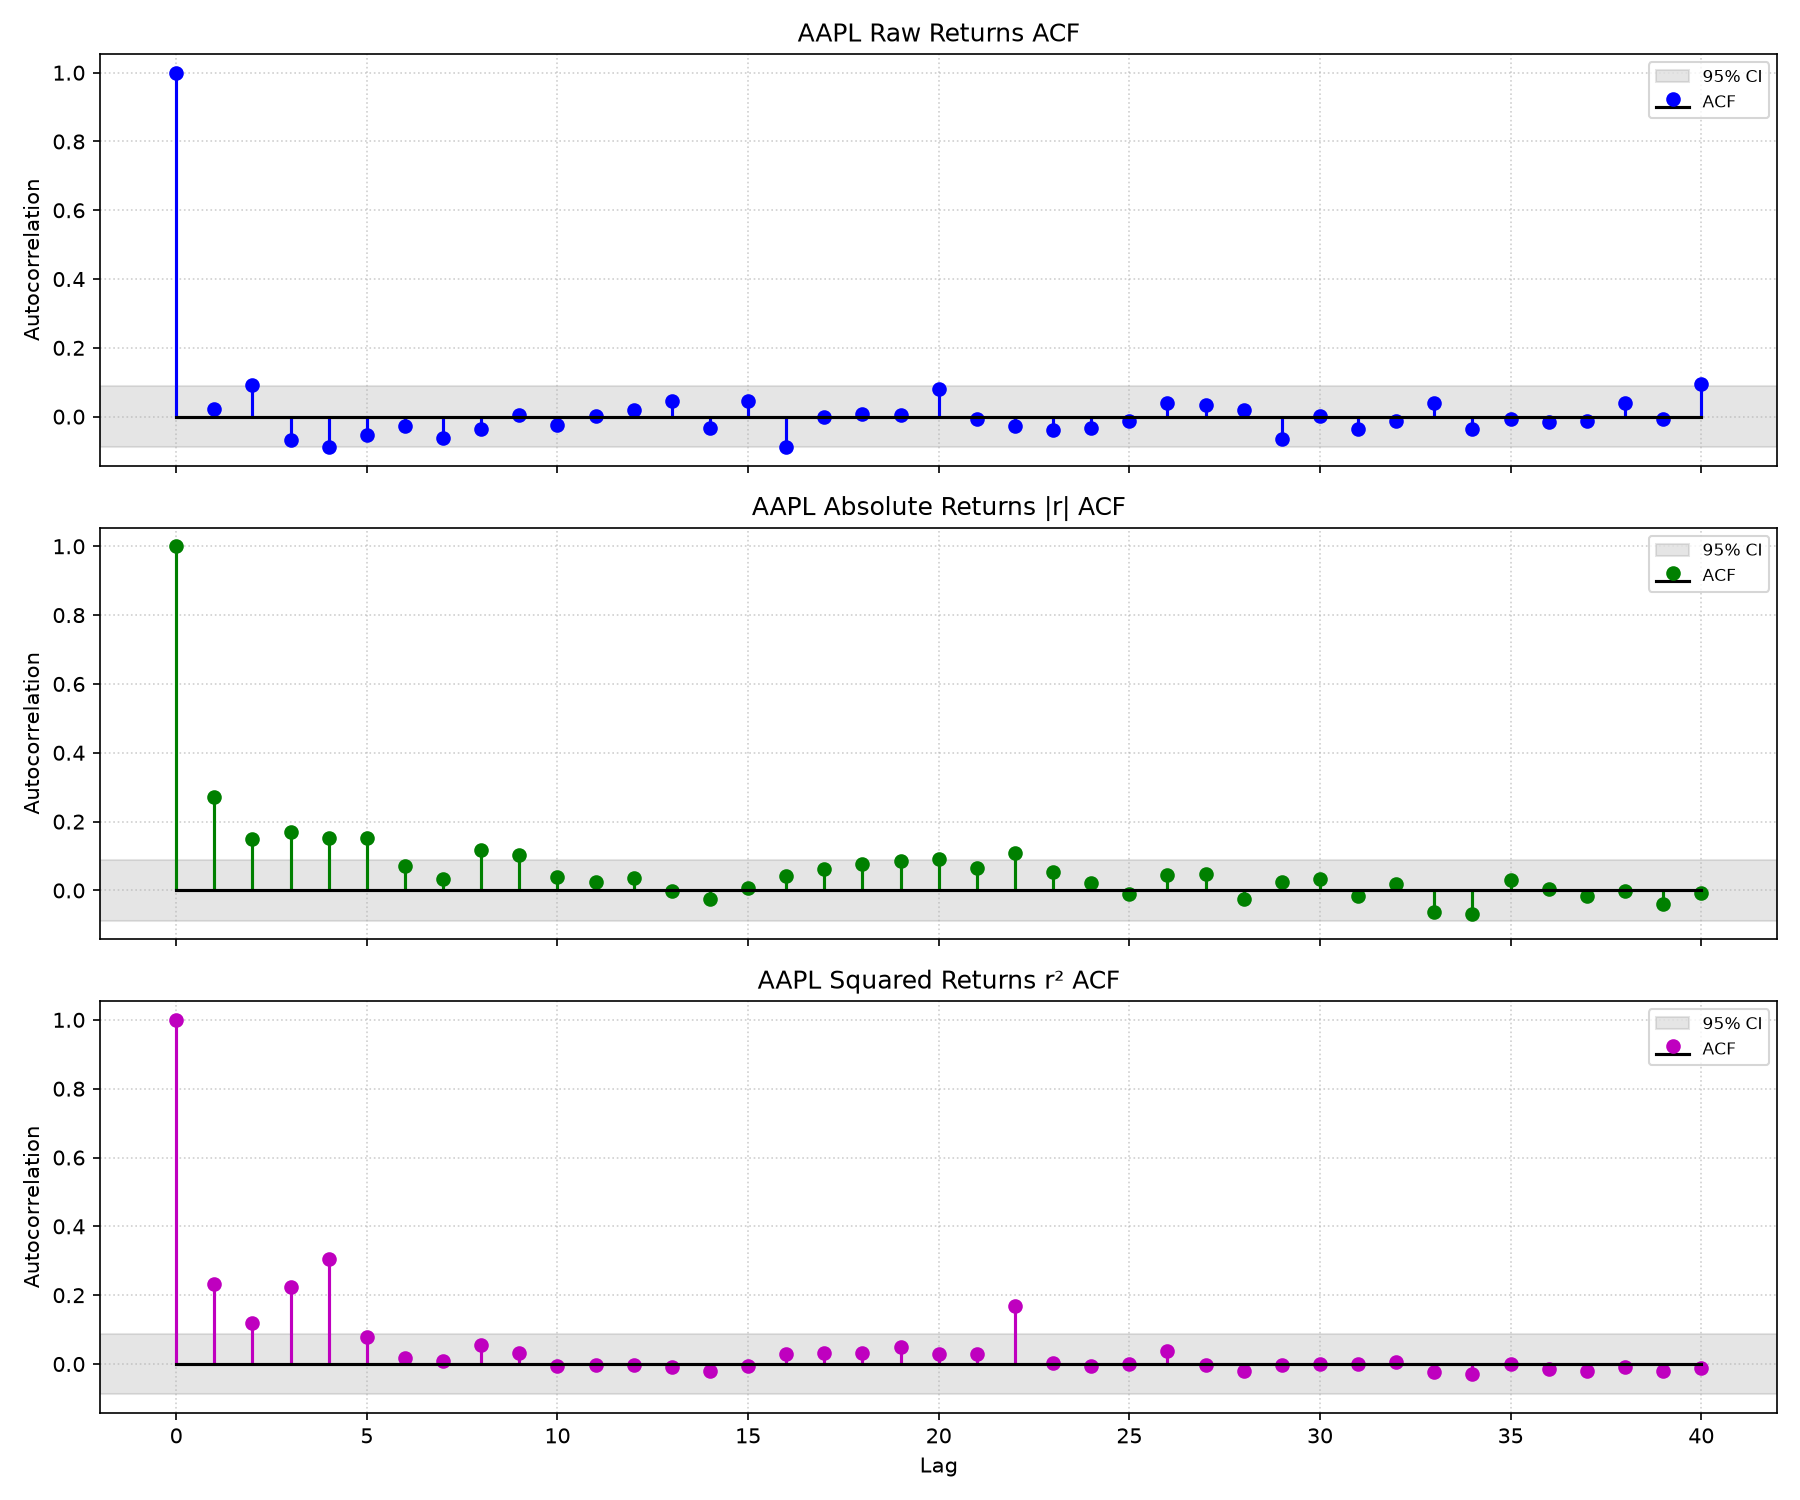

In [24]:
p = OUT_DIR / f"{TICKER}_correlogram.png"
display(Image(filename=str(p))) if p.exists() else print("(chart not generated for this run)")

### `AAPL_distribution.png`

In [25]:
print(inspect.getsource(report_builder.draw_distribution_chart))

def draw_distribution_chart(
    ticker: str,
    dist_data: dict,
    returns: pd.Series,
    out_path: Path,
) -> None:
    """Plot returns density histogram with fitted Normal and Student-t distributions."""
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ret_vals = returns.dropna().values
    
    n_bins = min(50, len(ret_vals) // 5) if len(ret_vals) > 50 else 15
    ax.hist(ret_vals, bins=n_bins, density=True, alpha=0.5, color="gray", edgecolor="black", label="Return Density")
    
    x_min, x_max = np.nanmin(ret_vals), np.nanmax(ret_vals)
    x_arr = np.linspace(x_min, x_max, 500)
    
    norm_fit = dist_data["normal_fit"]
    y_norm = scipy.stats.norm.pdf(x_arr, loc=norm_fit["loc"], scale=norm_fit["scale"])
    ax.plot(x_arr, y_norm, color="blue", linewidth=2, label=f"Normal Fit (std={norm_fit['scale']:.4f})")
    
    t_fit = dist_data["t_fit"]
    y_t = scipy.stats.t.pdf(x_arr, df=t_fit["df"], loc=t_fit["loc"], scale=t_fit["scale"])
    ax.plot(x_arr, y_t, color="red", 

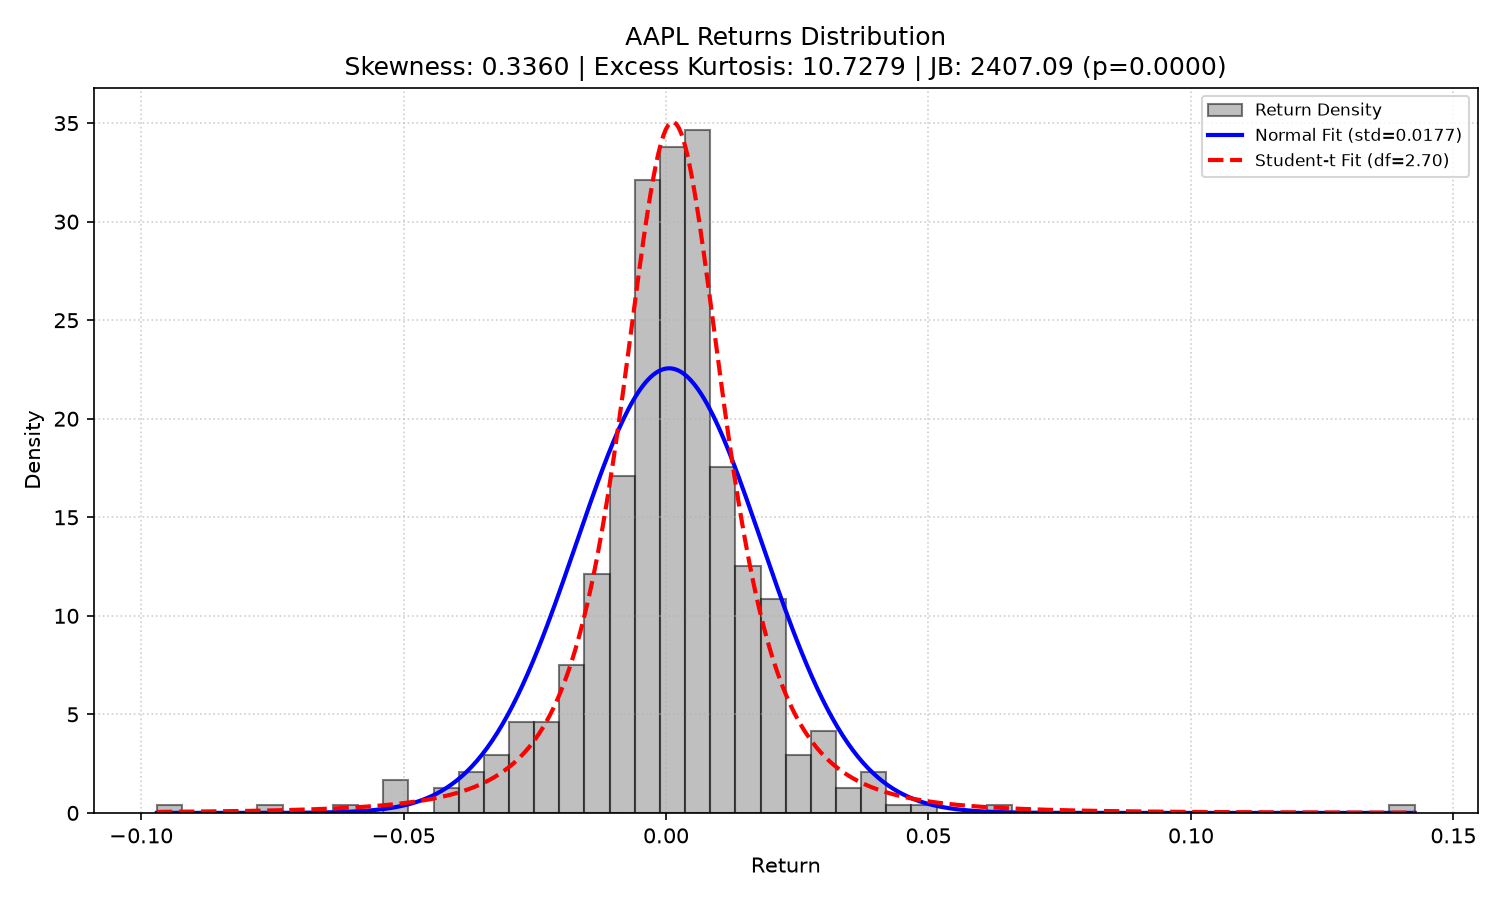

In [26]:
p = OUT_DIR / f"{TICKER}_distribution.png"
display(Image(filename=str(p))) if p.exists() else print("(chart not generated for this run)")

### `AAPL_52week.png`

In [27]:
print(inspect.getsource(report_builder.draw_52week_chart))

def draw_52week_chart(
    ticker: str,
    df: pd.DataFrame,
    stats_52w: dict,
    out_path: Path,
) -> None:
    """Plot price history with horizontal 52-week High/Low boundary lines.

    Only the 52-week window itself is plotted (not the full fetched history) so
    the High/Low lines actually bound the visible price — otherwise older prices
    outside the window would cross the lines and look wrong.
    """
    fig, ax = plt.subplots(figsize=(12, 6))

    window = int(stats_52w.get("window_used", len(df)))
    sub = df.iloc[-window:]
    ax.plot(sub.index, sub["Close"], label=f"{ticker} Close (last {window} bars)", color="#1f77b4", linewidth=1.5)

    high_val = stats_52w["high"]
    low_val = stats_52w["low"]
    curr_val = stats_52w["current"]

    ax.axhline(high_val, color="red", linestyle="--", alpha=0.7, label=f"52w High ({high_val:.2f})")
    ax.axhline(low_val, color="green", linestyle="--", alpha=0.7, label=f"52w Low ({low_val:.2f})")

    ax.scatter(sub.index[-1], cu

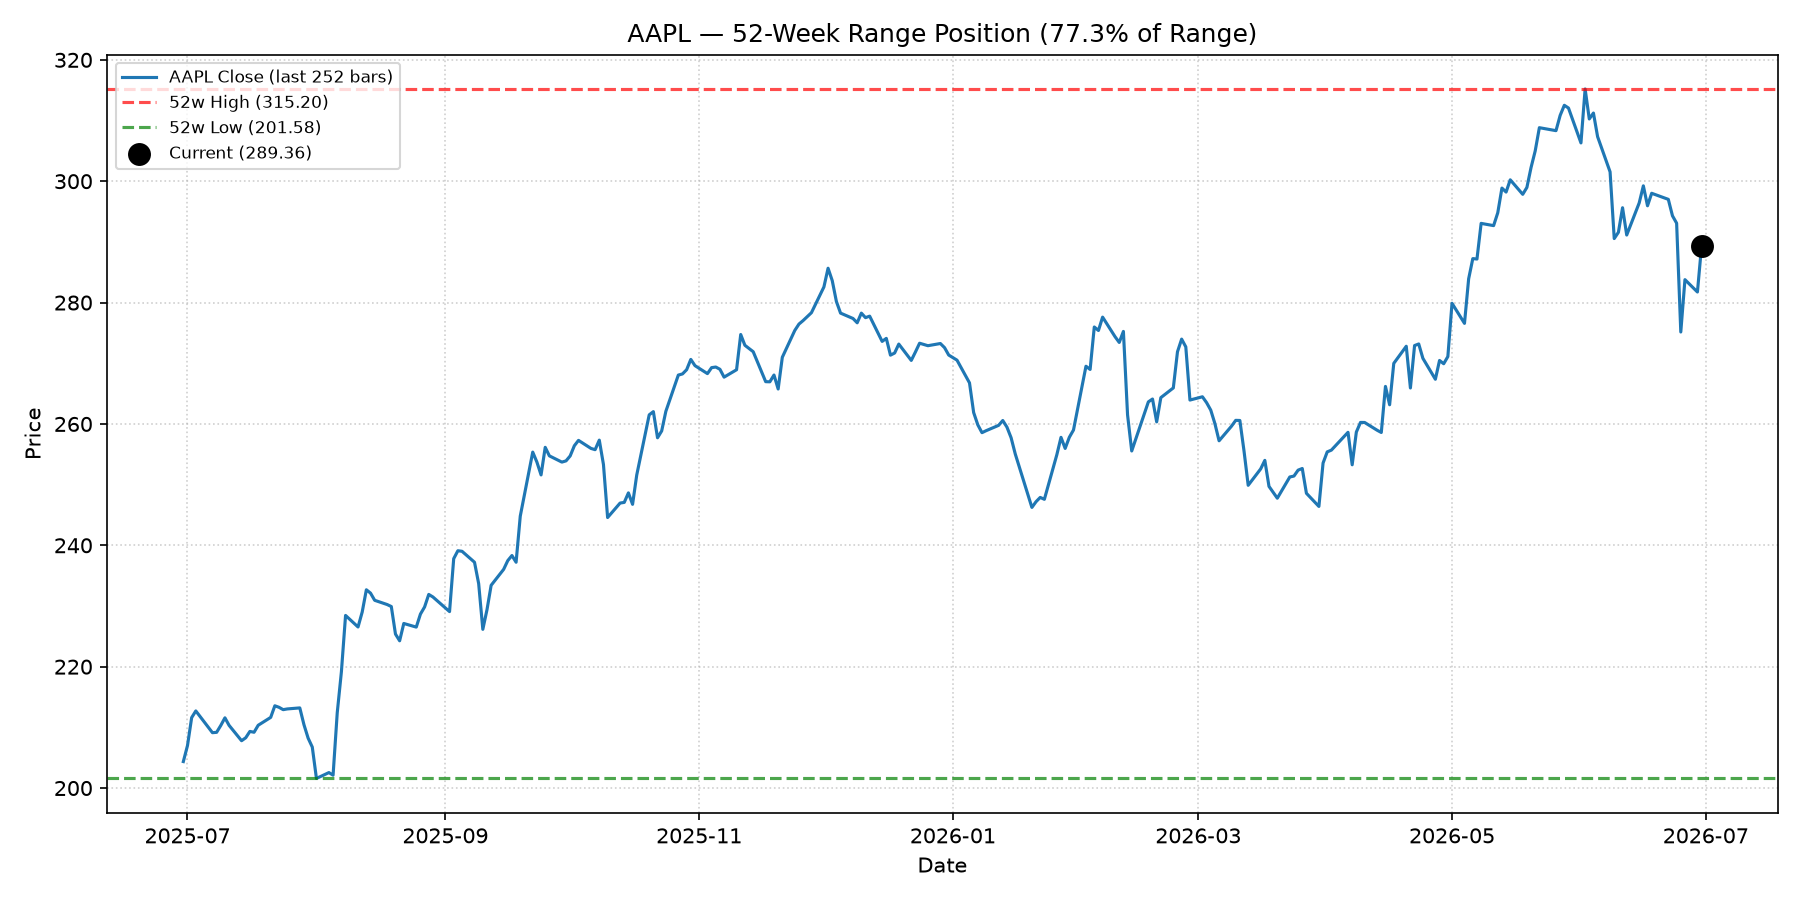

In [28]:
p = OUT_DIR / f"{TICKER}_52week.png"
display(Image(filename=str(p))) if p.exists() else print("(chart not generated for this run)")

### `AAPL_drawdown.png`

In [29]:
print(inspect.getsource(report_builder.draw_drawdown_chart))

def draw_drawdown_chart(
    ticker: str,
    dd_series: pd.DataFrame,
    out_path: Path,
) -> None:
    """Plot underwater drawdown equity curve."""
    fig, ax = plt.subplots(figsize=(12, 5))
    
    dd_pct = dd_series["drawdown"] * 100.0
    
    ax.plot(dd_pct.index, dd_pct, color="darkred", linewidth=1.2, label="Drawdown %")
    ax.fill_between(dd_pct.index, dd_pct, 0.0, color="red", alpha=0.25)
    ax.axhline(0.0, color="black", linestyle="-", linewidth=1.0)
    
    ax.set_ylabel("Drawdown %")
    ax.set_xlabel("Date")
    ax.set_title(f"{ticker} — Historical Drawdown (Underwater Curve)")
    ax.legend(loc="lower left", fontsize=8)
    ax.grid(True, linestyle=":", alpha=0.6)
    
    plt.tight_layout()
    _save(fig, out_path)



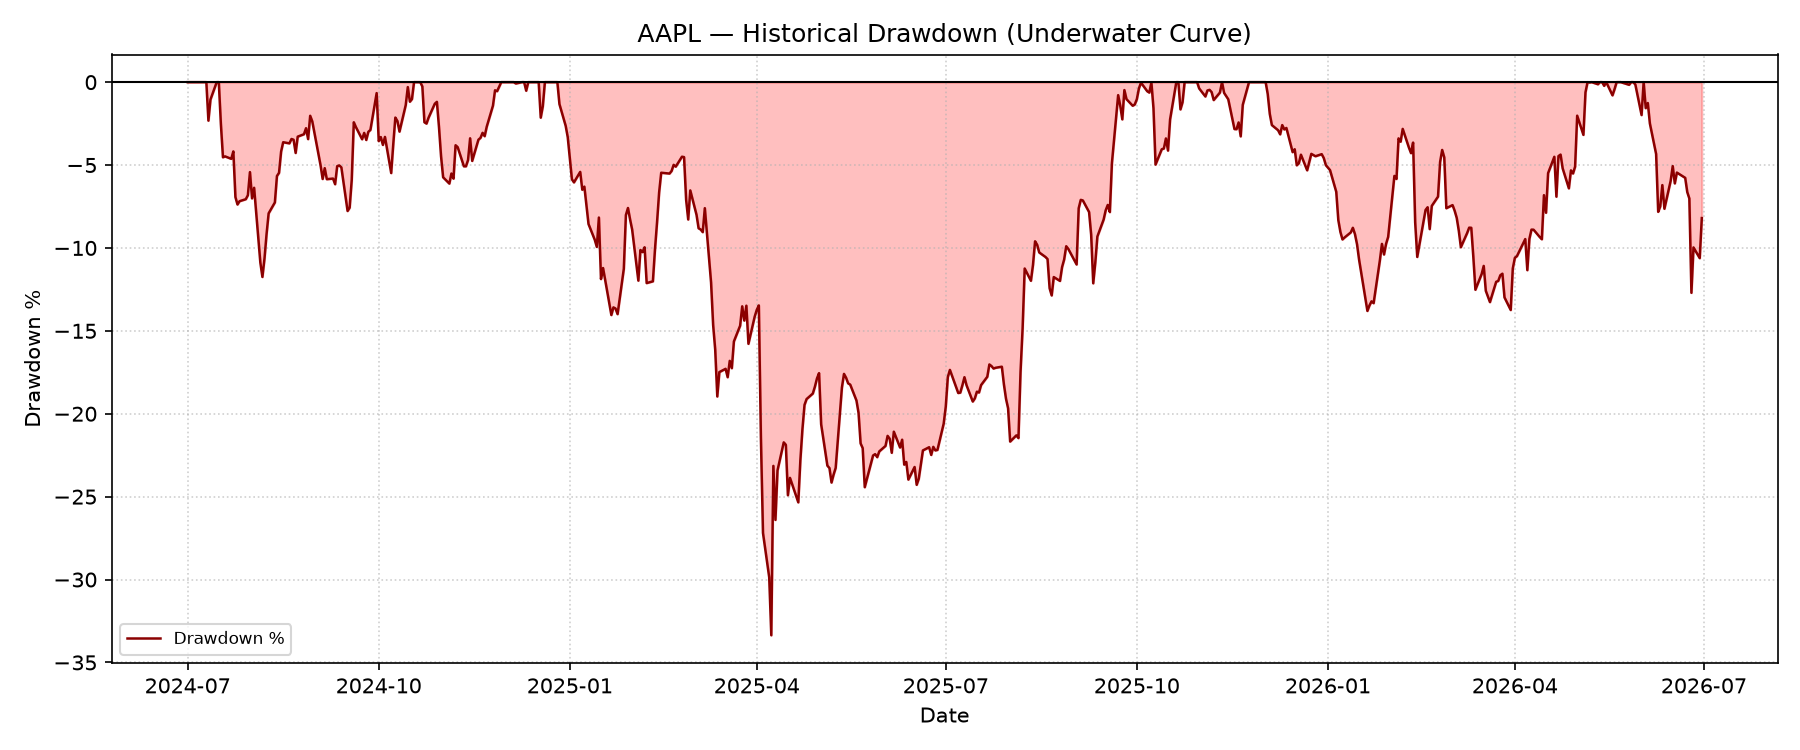

In [30]:
p = OUT_DIR / f"{TICKER}_drawdown.png"
display(Image(filename=str(p))) if p.exists() else print("(chart not generated for this run)")

### `AAPL_beta.png`

In [31]:
print(inspect.getsource(report_builder.draw_beta_chart))

def draw_beta_chart(
    ticker: str,
    stock_ret: pd.Series,
    bench_ret: pd.Series,
    beta: float,
    alpha_daily: float,
    out_path: Path,
) -> None:
    """Plot returns scatter plot of asset vs benchmark with regression line."""
    fig, ax = plt.subplots(figsize=(8, 6))
    
    aligned = pd.concat([stock_ret, bench_ret], axis=1, join="inner").dropna()
    if len(aligned) < 2:
        _save(fig, out_path)
        return
        
    s_vals = aligned.iloc[:, 0].values
    b_vals = aligned.iloc[:, 1].values
    
    ax.scatter(b_vals, s_vals, color="gray", alpha=0.5, edgecolors="none", label="Daily Returns")
    
    x_arr = np.linspace(np.nanmin(b_vals), np.nanmax(b_vals), 100)
    y_arr = beta * x_arr + alpha_daily
    ax.plot(x_arr, y_arr, color="blue", linewidth=2, label=f"Regression (Beta={beta:.2f})")
    
    ax.set_xlabel("Benchmark Returns")
    ax.set_ylabel(f"{ticker} Returns")
    ax.set_title(f"{ticker} Systematic Risk (Beta vs Benchmark)")
    ax.legend(loc="u

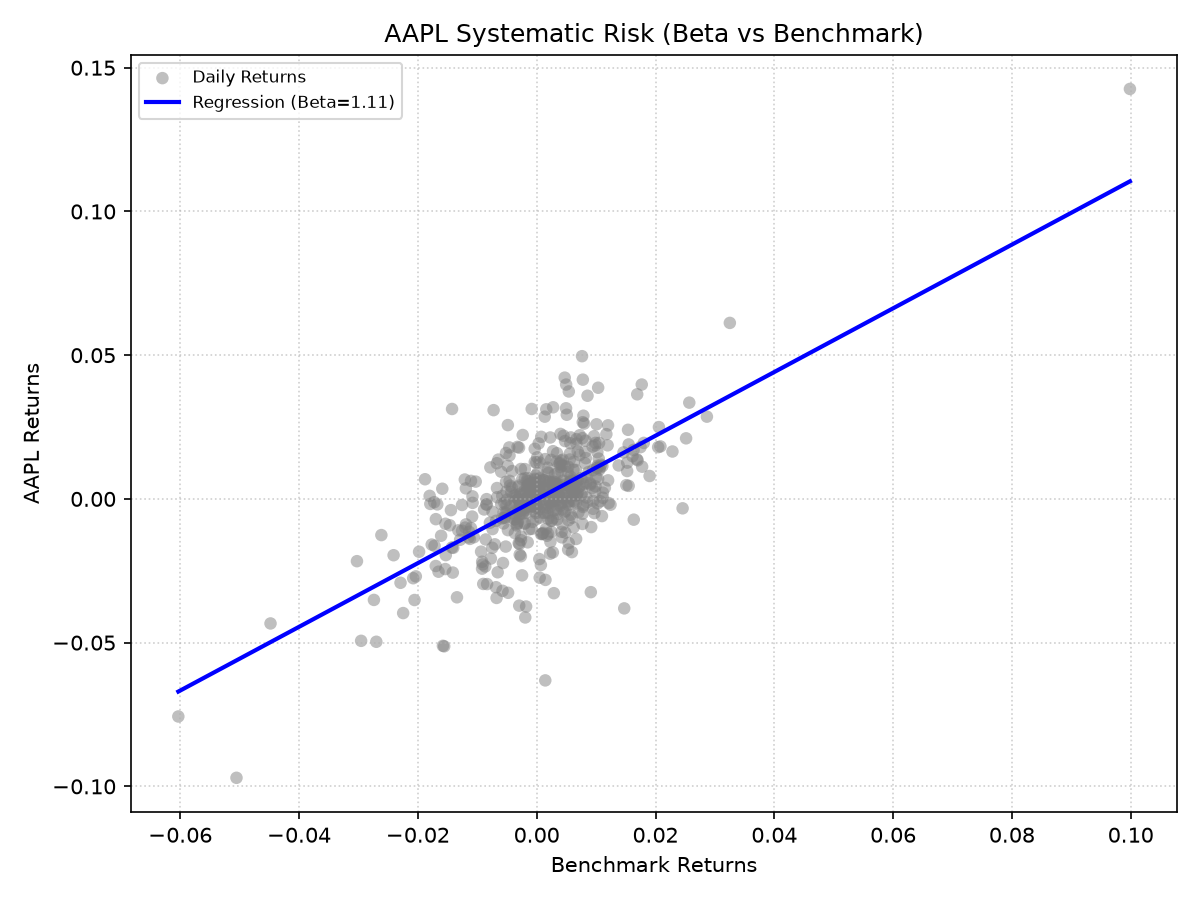

In [32]:
p = OUT_DIR / f"{TICKER}_beta.png"
display(Image(filename=str(p))) if p.exists() else print("(chart not generated for this run)")

### `AAPL_structural_breaks.png`

In [33]:
print(inspect.getsource(report_builder.draw_structural_breaks_chart))

def draw_structural_breaks_chart(
    ticker: str,
    df: pd.DataFrame,
    breaks: list[dict],
    out_path: Path,
) -> None:
    """Plot price series with vertical structural breaks and shaded regime bands."""
    fig, ax = plt.subplots(figsize=(12, 6))
    
    ax.plot(df.index, df["Close"], color="#1f77b4", linewidth=1.5, label=f"{ticker} Close")
    
    sorted_breaks = sorted(breaks, key=lambda x: x["index"])
    colors = ["#1f77b4", "#2ca02c", "#ff7f0e", "#9467bd", "#8c564b"]
    
    # Break indices come from the returns series (len = len(df)-1), clamp to df range
    max_idx = len(df) - 1
    break_indices = [0] + [min(b["index"], max_idx) for b in sorted_breaks] + [max_idx]
    
    for i in range(len(break_indices) - 1):
        start_idx = break_indices[i]
        end_idx = break_indices[i+1]
        
        start_date = df.index[start_idx]
        end_date = df.index[end_idx]
        
        color = colors[i % len(colors)]
        ax.axvspan(start_date, end_date, color=

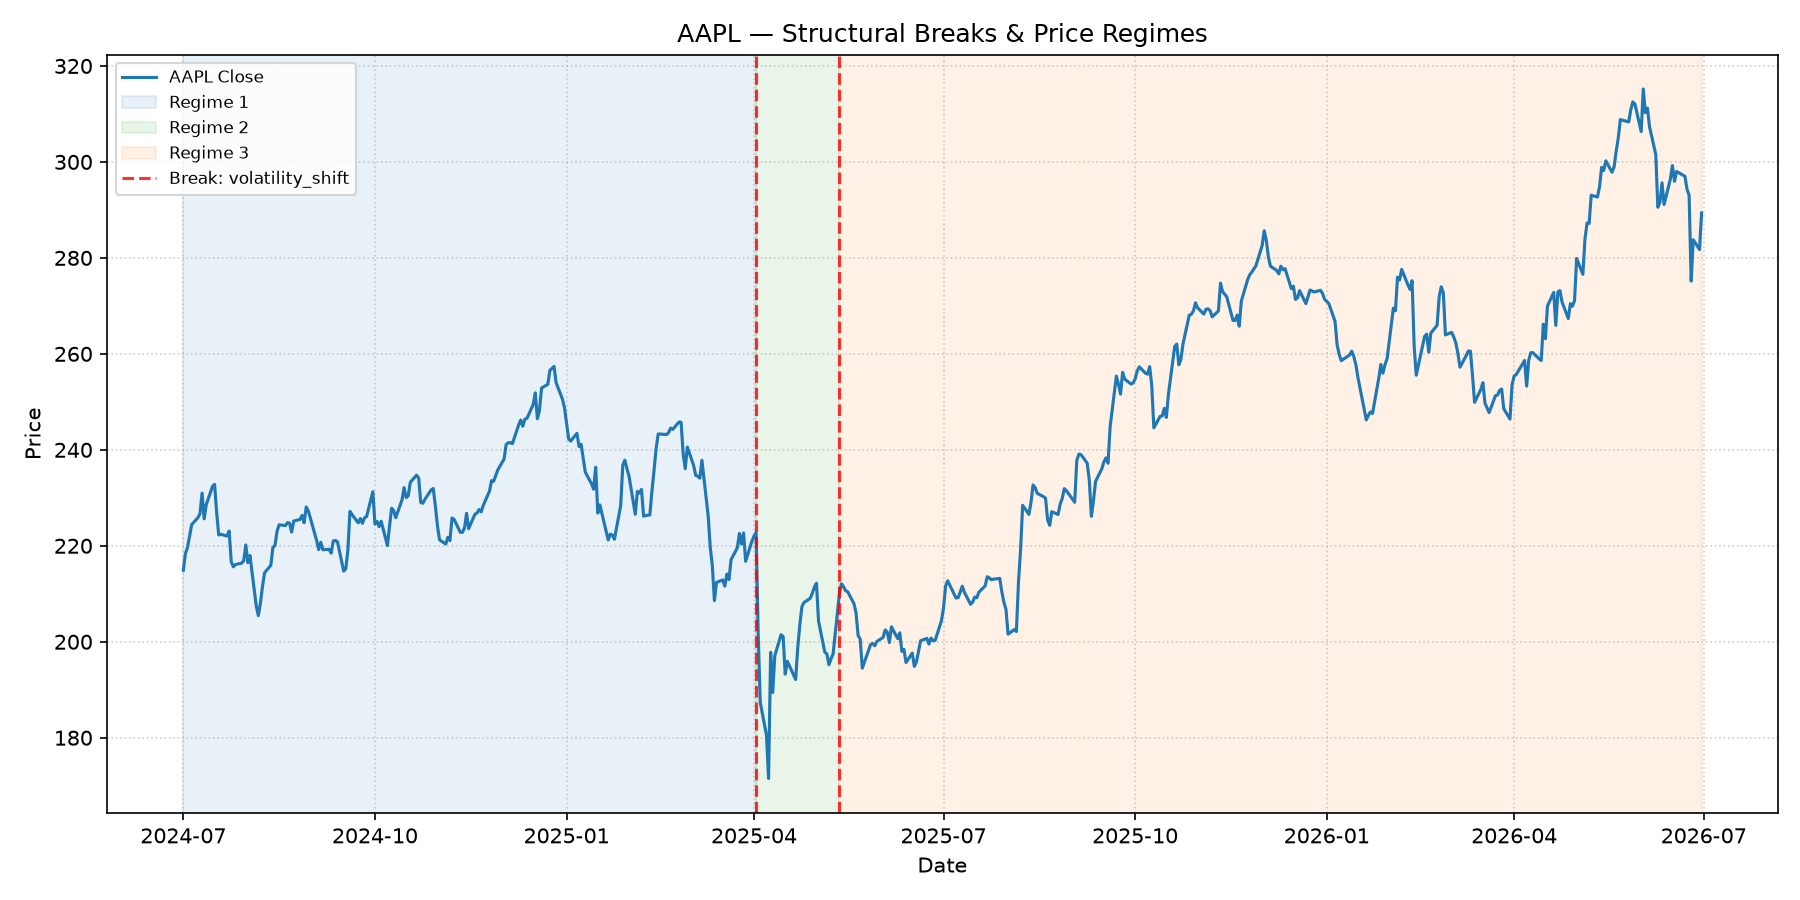

In [34]:
p = OUT_DIR / f"{TICKER}_structural_breaks.png"
display(Image(filename=str(p))) if p.exists() else print("(chart not generated for this run)")

### `AAPL_hurst.png`

In [35]:
print(inspect.getsource(report_builder.draw_hurst_chart))

def draw_hurst_chart(
    ticker: str,
    ret_h: dict,
    vol_h: dict,
    out_path: Path,
) -> None:
    """Plot rescaled range log-log line for returns and volatility."""
    fig, ax = plt.subplots(figsize=(8, 6))
    
    if len(ret_h.get("scales", [])) >= 2:
        scales = np.array(ret_h["scales"])
        rs_vals = np.array(ret_h["rs_values"])
        ax.scatter(np.log(scales), np.log(rs_vals), color="blue", alpha=0.7, label=f"Returns R/S (H={ret_h['hurst']:.2f})")
        coeffs = np.polyfit(np.log(scales), np.log(rs_vals), 1)
        ax.plot(np.log(scales), np.polyval(coeffs, np.log(scales)), color="blue", linestyle="--")
        
    if len(vol_h.get("scales", [])) >= 2:
        scales = np.array(vol_h["scales"])
        rs_vals = np.array(vol_h["rs_values"])
        ax.scatter(np.log(scales), np.log(rs_vals), color="purple", alpha=0.7, label=f"Volatility R/S (H={vol_h['hurst']:.2f})")
        coeffs = np.polyfit(np.log(scales), np.log(rs_vals), 1)
        ax.plot(np.log(sc

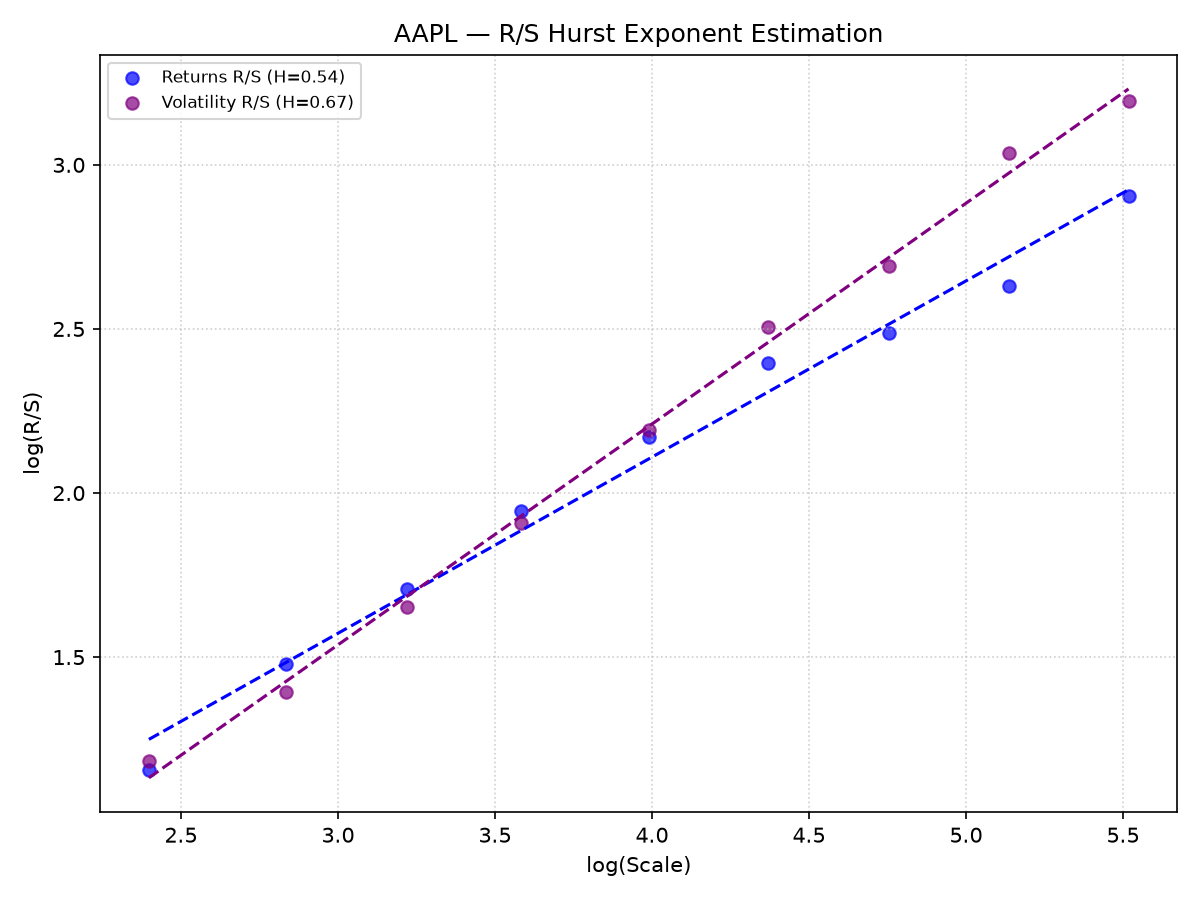

In [36]:
p = OUT_DIR / f"{TICKER}_hurst.png"
display(Image(filename=str(p))) if p.exists() else print("(chart not generated for this run)")

### `AAPL_quantile_beta.png`

In [37]:
print(inspect.getsource(report_builder.draw_quantile_beta_chart))

def draw_quantile_beta_chart(
    ticker: str,
    qbeta_res: dict,
    out_path: Path,
) -> None:
    """Plot quantile beta values with confidence interval bands and OLS beta reference."""
    fig, ax = plt.subplots(figsize=(8, 6))
    
    quantiles = qbeta_res["quantiles"]
    betas = [qbeta_res["betas"][q] for q in quantiles]
    ci_low = [qbeta_res["cis"][q][0] for q in quantiles]
    ci_high = [qbeta_res["cis"][q][1] for q in quantiles]
    
    ols_val = qbeta_res["ols_beta"]
    ax.axhline(ols_val, color="red", linestyle="--", linewidth=1.5, label=f"OLS Beta ({ols_val:.2f})")
    
    ax.plot(quantiles, betas, color="blue", marker="o", linewidth=2, label="Quantile Beta")
    ax.fill_between(quantiles, ci_low, ci_high, color="blue", alpha=0.15, label="95% Confidence Interval")
    
    ax.set_xlabel("Quantile (tau)")
    ax.set_ylabel("Beta Coefficient")
    ax.set_title(f"{ticker} — Conditional Beta Across Quantiles (Quantile Regression)")
    ax.set_xticks(quantiles)
    ax.le

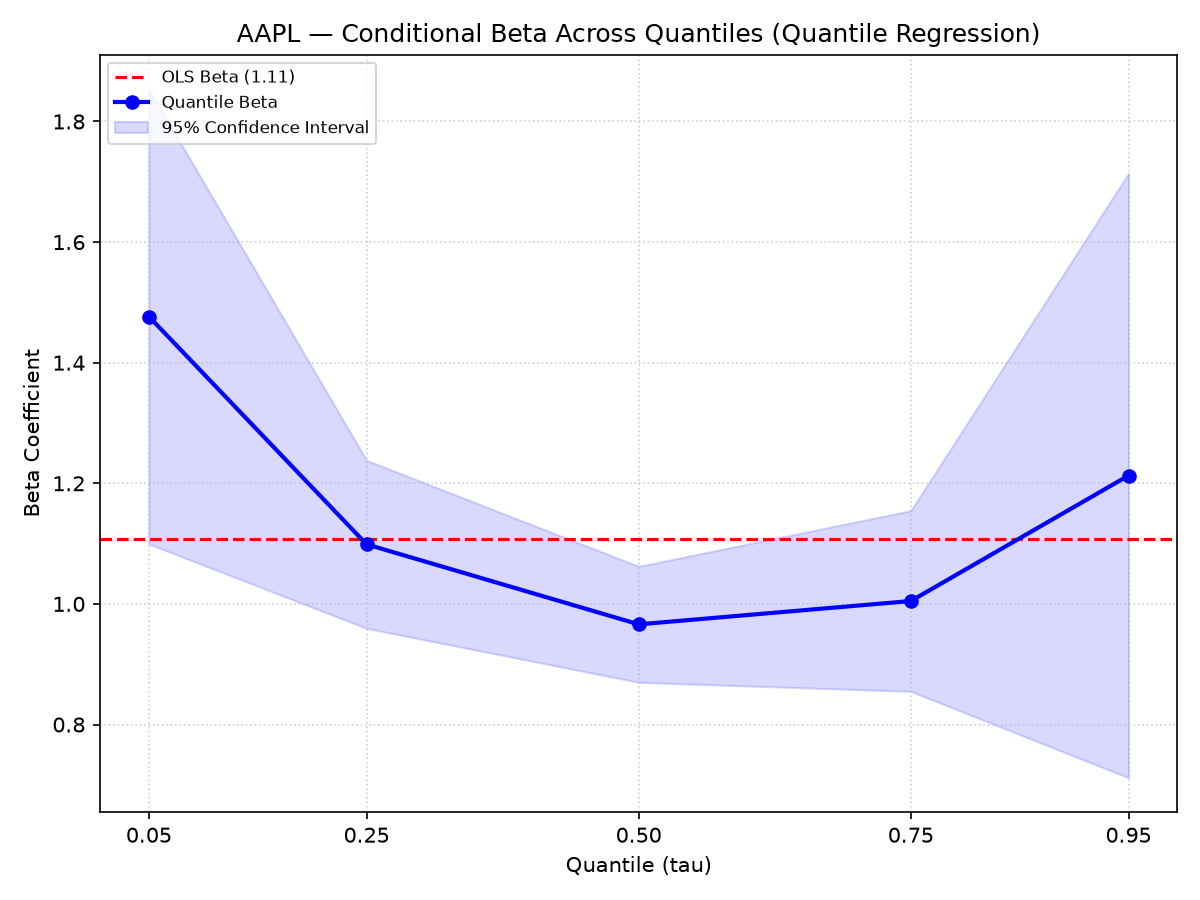

In [38]:
p = OUT_DIR / f"{TICKER}_quantile_beta.png"
display(Image(filename=str(p))) if p.exists() else print("(chart not generated for this run)")

## 5. Live test suite run

In [39]:
import subprocess

test_result = subprocess.run(
    [sys.executable, "-m", "pytest", "-q"],
    cwd=str(ROOT),
    capture_output=True,
    text=True,
)
print(test_result.stdout[-1500:])
print(f"\npytest exit code: {test_result.returncode}")

s_econometrics_alive
  C:\Users\armut\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\quantile_regression.py:203: RuntimeWarning: invalid value encountered in divide
    fhat0 = 1. / (nobs * h) * np.sum(kernel(e / h))

tests/test_numerical_stability.py::test_zero_price_pipeline_keeps_econometrics_alive
  C:\Users\armut\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\quantile_regression.py:236: RuntimeWarning: invalid value encountered in multiply
    kernels['epa'] = lambda u: 3. / 4 * (1-u**2) * np.where(np.abs(u) <= 1, 1, 0)

tests/test_statistical_rigor.py::test_period_arg_and_tail_warning
tests/test_statistical_rigor.py::test_period_arg_and_tail_warning
tests/test_statistical_rigor.py::test_period_arg_and_tail_warning
  C:\Users\armut\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\stattools.py:702: RuntimeWarning: invalid value encountered in divide
    acf = avf[: nlags + 1] / avf[0]

test

## 6. Summary

| What | Result |
|---|---|
| End-to-end run on a real ticker (AAPL) | see Section 1 |
| Terminal dashboard | see Section 2 |
| Plain-English finding per module (11 modules) | see Section 3 |
| Charts generated | see Section 4 (embedded, standalone-portable) |
| Offline test suite | see Section 5 |

For independent verification of the underlying indicator *math* (not just
that the tool runs), see `notebooks/proof_of_correctness.ipynb`.